# Step 0b: Expanded Features EDA

This notebook explores the expanded feature set (26 features) with signal-type-aware preprocessing.

## Contents
1. Load data and visualize features by signal type
2. NaN patterns in offline features
3. Interpolation effects
4. Smoothing effects on noisy signals
5. Normalization statistics
6. Domain comparison (source vs target)

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_batches
from src.feature_config import (
    INPUT_FEATURES_EXPANDED,
    STEP_WISE_FEATURES,
    SPIKY_SPARSE_FEATURES,
    NOISY_TREND_FEATURES,
    NOISY_SHORT_TREND_FEATURES,
    TREND_JUMP_FEATURES,
    SPARSE_OFFLINE_FEATURES,
    get_signal_type,
)
from src.preprocessing import (
    extract_early_window,
    interpolate_sparse_feature,
    preprocess_expanded_features,
    compute_normalization_stats_expanded,
)
from src.domain_splits import get_control_mode_split

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

In [2]:
# Load data
batches = load_batches()
splits = get_control_mode_split()
print(f"Loaded {len(batches)} batches")
print(f"Expanded feature set: {len(INPUT_FEATURES_EXPANDED)} features")

Loaded 100 batches
Expanded feature set: 25 features


## 1. Visualize Features by Signal Type

Group and plot the 26 features organized by their signal type.

In [3]:
# Select one batch for visualization
batch_id = 34
df = batches[batch_id]

# Define feature groups with labels
feature_groups = {
    "Step-wise (control signals)": STEP_WISE_FEATURES,
    "Spiky/Sparse (intermittent)": SPIKY_SPARSE_FEATURES,
    "Noisy with Trend": NOISY_TREND_FEATURES,
    "Noisy Short Trend": NOISY_SHORT_TREND_FEATURES,
    "Trend with Jumps": TREND_JUMP_FEATURES,
    "Sparse Offline Measurements": SPARSE_OFFLINE_FEATURES,
}

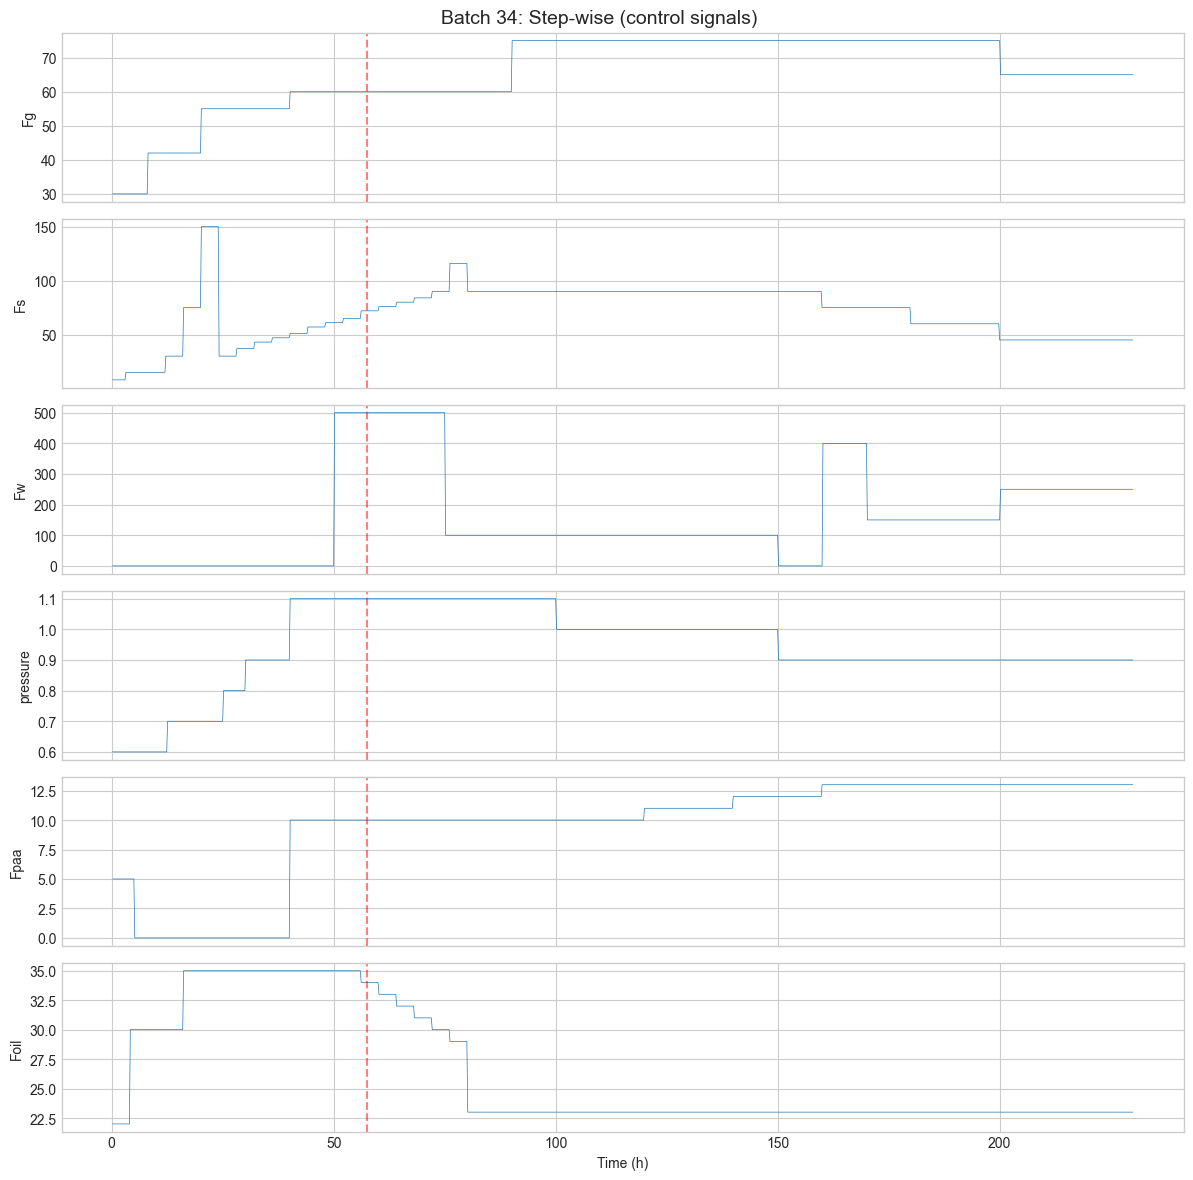

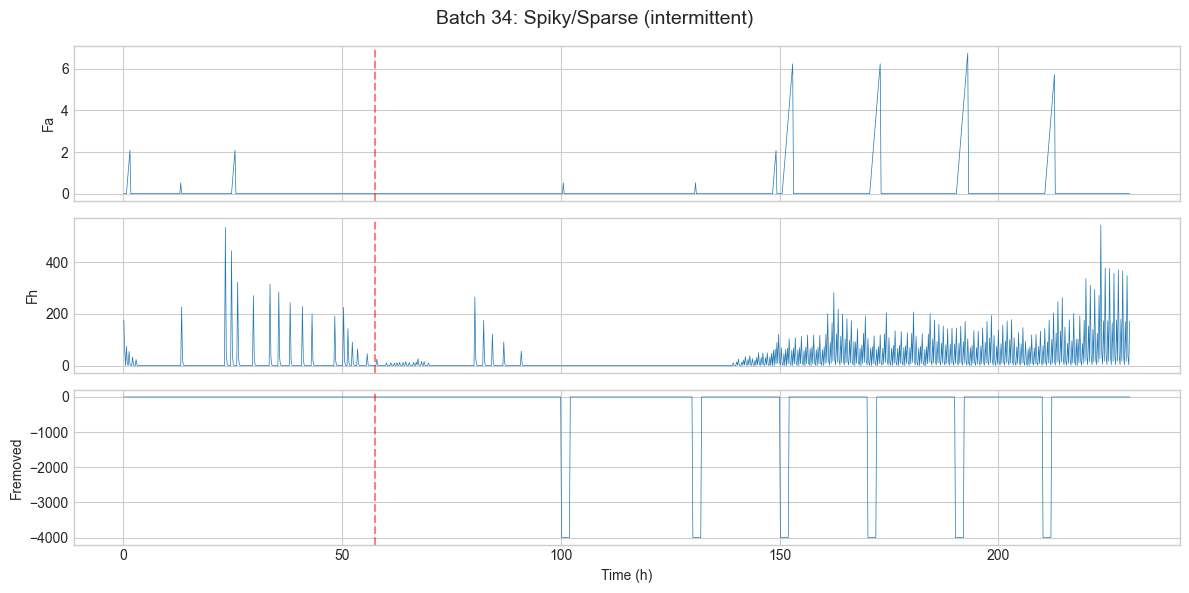

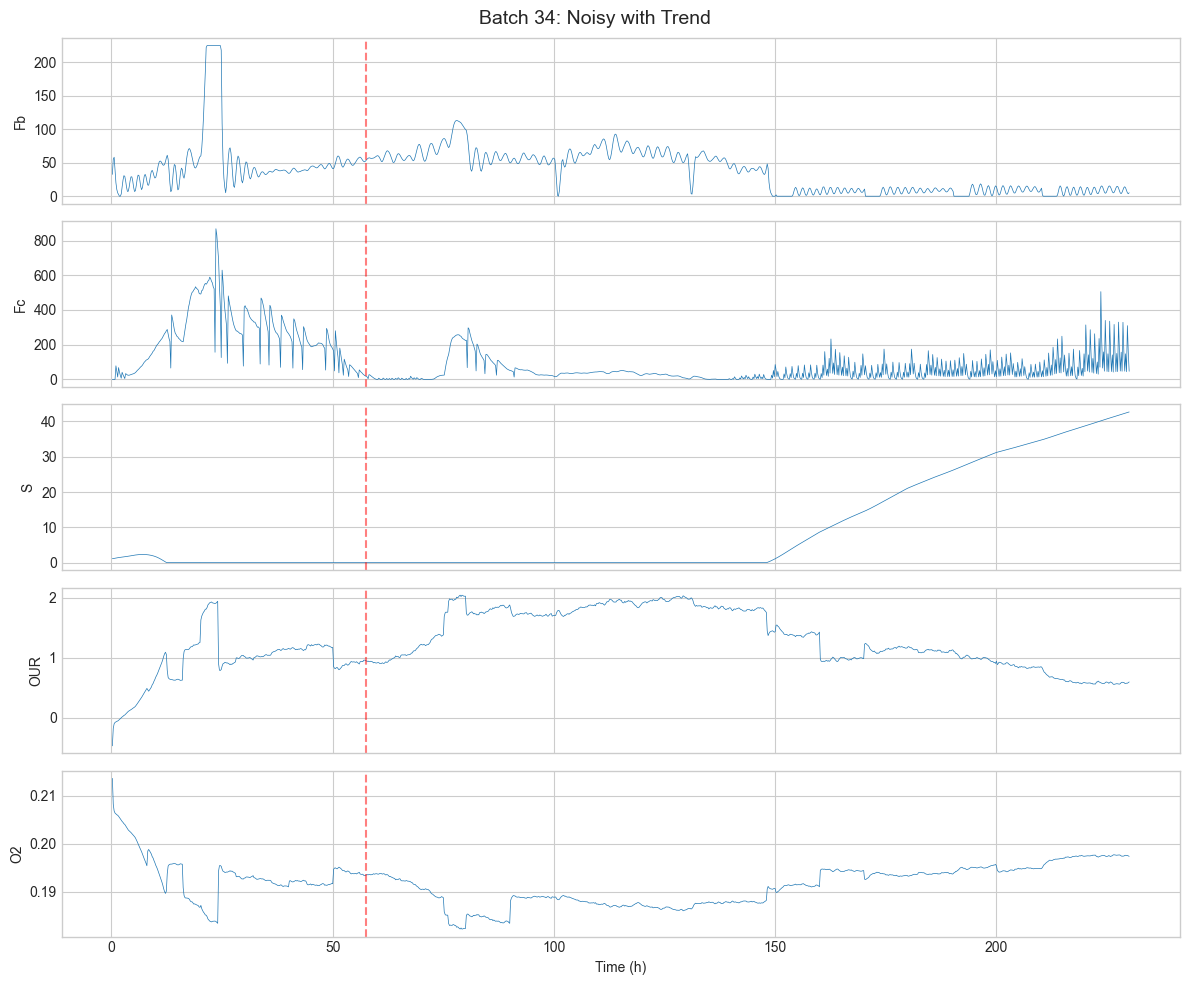

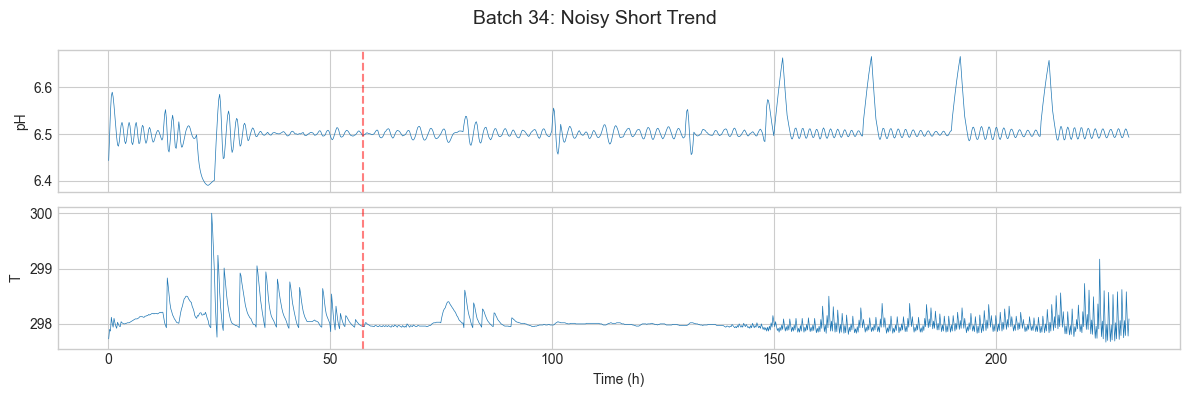

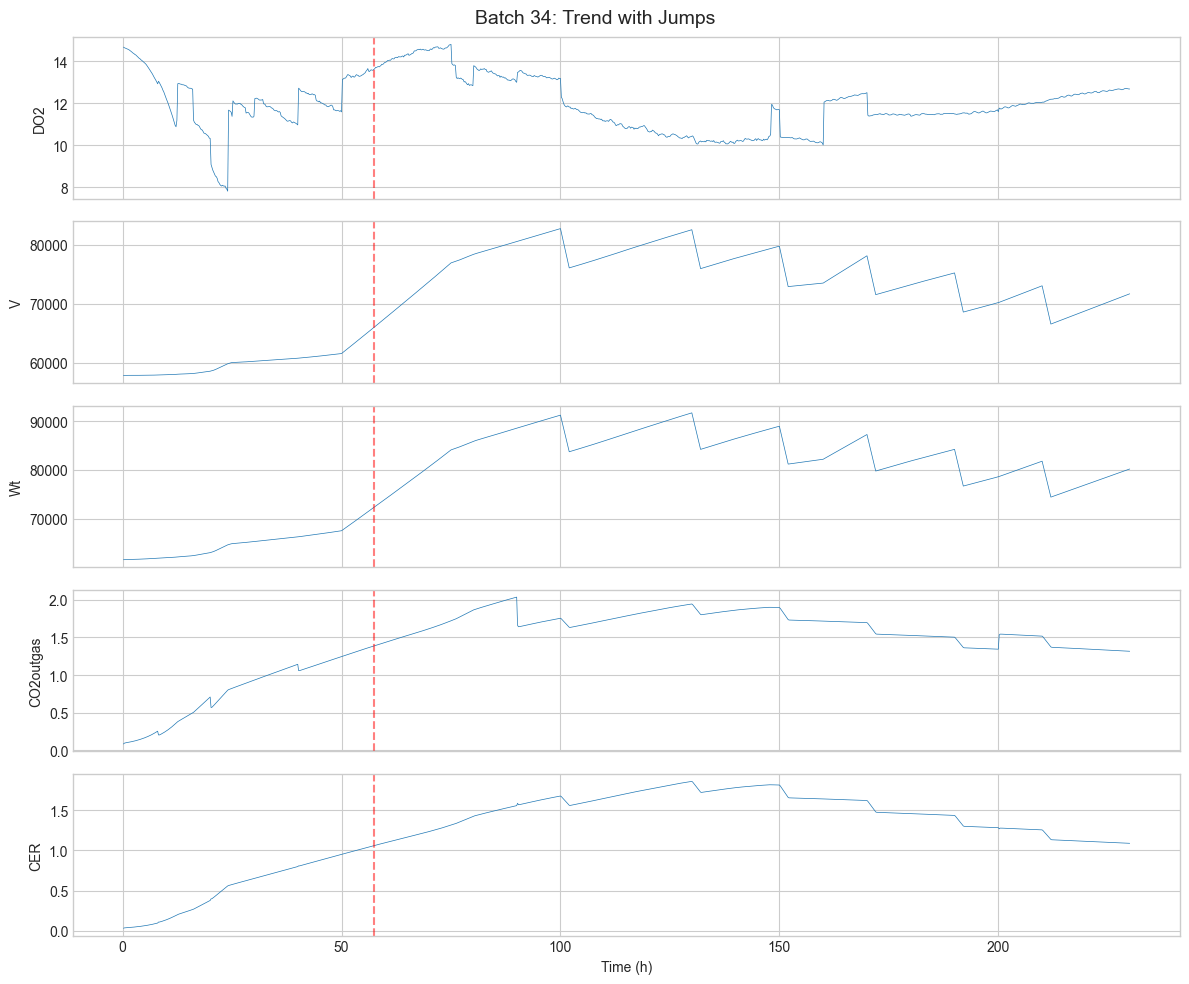

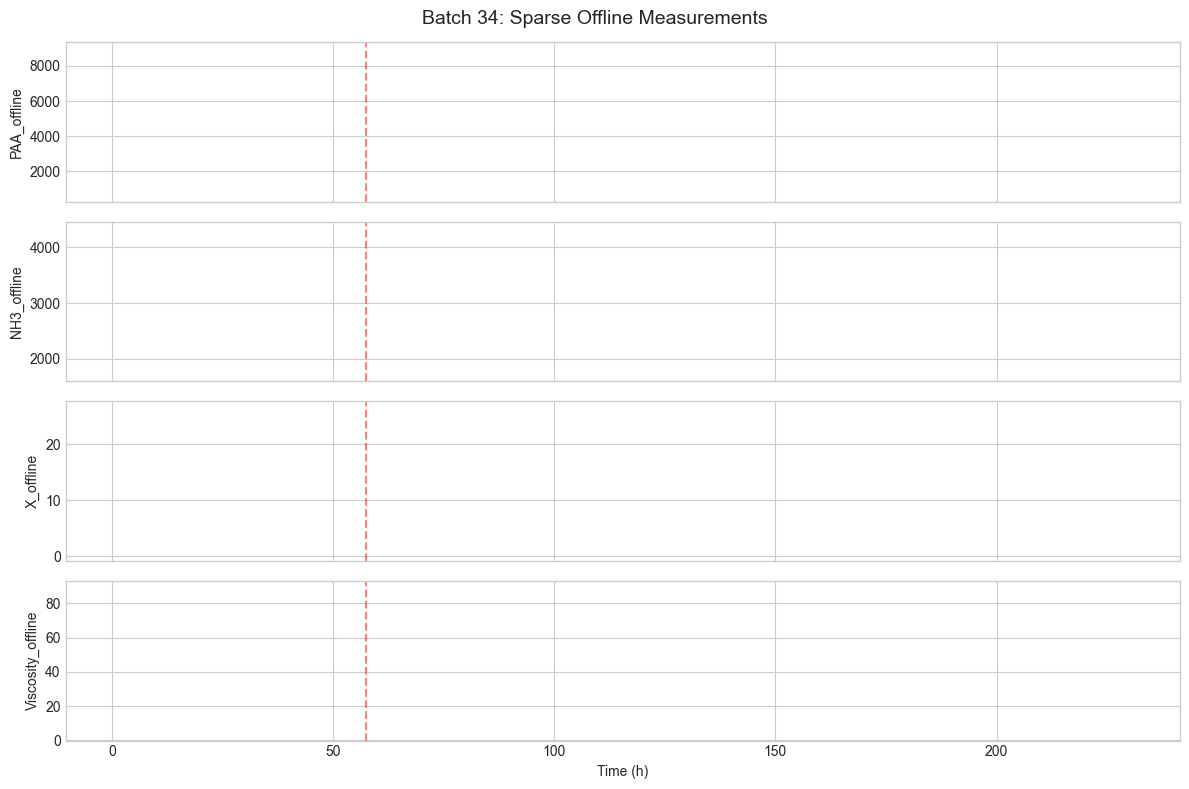

In [4]:
# Plot each feature group
for group_name, features in feature_groups.items():
    available = [f for f in features if f in df.columns]
    if not available:
        print(f"No features available for: {group_name}")
        continue
    
    n_features = len(available)
    fig, axes = plt.subplots(n_features, 1, figsize=(12, 2 * n_features), sharex=True)
    if n_features == 1:
        axes = [axes]
    
    fig.suptitle(f"Batch {batch_id}: {group_name}", fontsize=14)
    
    for ax, feat in zip(axes, available):
        ax.plot(df["time"], df[feat], linewidth=0.5)
        ax.set_ylabel(feat)
        ax.axvline(df["time"].max() * 0.25, color="red", linestyle="--", alpha=0.5, label="25% window")
    
    axes[-1].set_xlabel("Time (h)")
    plt.tight_layout()
    plt.show()

## 2. NaN Patterns in Offline Features

Examine the sparsity of offline measurements across batches.

In [5]:
# Compute NaN statistics for sparse features across all batches
nan_stats = []

for batch_id in splits["source"] + splits["target"]:
    df = batches[batch_id]
    early = extract_early_window(df, 0.25)
    
    for feat in SPARSE_OFFLINE_FEATURES:
        if feat in early.columns:
            total = len(early)
            non_nan = early[feat].notna().sum()
            nan_frac = 1 - (non_nan / total)
            nan_stats.append({
                "batch_id": batch_id,
                "feature": feat,
                "total_points": total,
                "non_nan_points": non_nan,
                "nan_fraction": nan_frac,
            })

nan_df = pd.DataFrame(nan_stats)
nan_df.head(10)

,batch_id,feature,total_points,non_nan_points,nan_fraction
0,1,PAA_offline,282,5,0.982270
1,1,NH3_offline,282,5,0.982270
2,1,X_offline,282,5,0.982270
3,1,Viscosity_offline,282,5,0.982270
4,2,PAA_offline,287,5,0.982578
5,2,NH3_offline,287,5,0.982578
6,2,X_offline,287,5,0.982578
7,2,Viscosity_offline,287,5,0.982578
8,3,PAA_offline,347,6,0.982709
9,3,NH3_offline,347,6,0.982709


In [6]:
# Summarize NaN fractions by feature
nan_summary = nan_df.groupby("feature")["nan_fraction"].agg(["mean", "std", "min", "max"])
print("NaN fraction statistics for sparse offline features (early window):")
print(nan_summary.round(3))

NaN fraction statistics for sparse offline features (early window):
                    mean    std    min    max
feature                                      
NH3_offline        0.982  0.001  0.979  0.983
PAA_offline        0.982  0.001  0.979  0.983
Viscosity_offline  0.982  0.001  0.979  0.983
X_offline          0.982  0.001  0.979  0.983


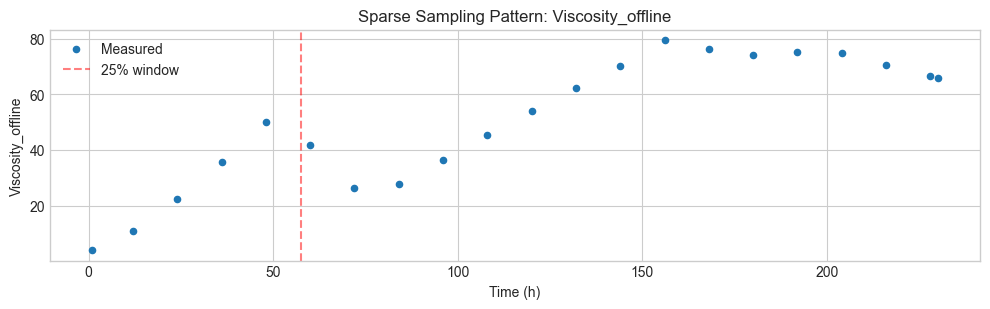

In [7]:
# Visualize NaN pattern for one sparse feature
feat = "Viscosity_offline"
if feat in df.columns:
    fig, ax = plt.subplots(figsize=(12, 3))
    
    # Plot non-NaN values as dots
    mask = df[feat].notna()
    ax.scatter(df.loc[mask, "time"], df.loc[mask, feat], s=20, label="Measured")
    ax.axvline(df["time"].max() * 0.25, color="red", linestyle="--", alpha=0.5, label="25% window")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(feat)
    ax.set_title(f"Sparse Sampling Pattern: {feat}")
    ax.legend()
    plt.show()

## 3. Interpolation Effects

Demonstrate the interpolation strategy for sparse offline measurements.

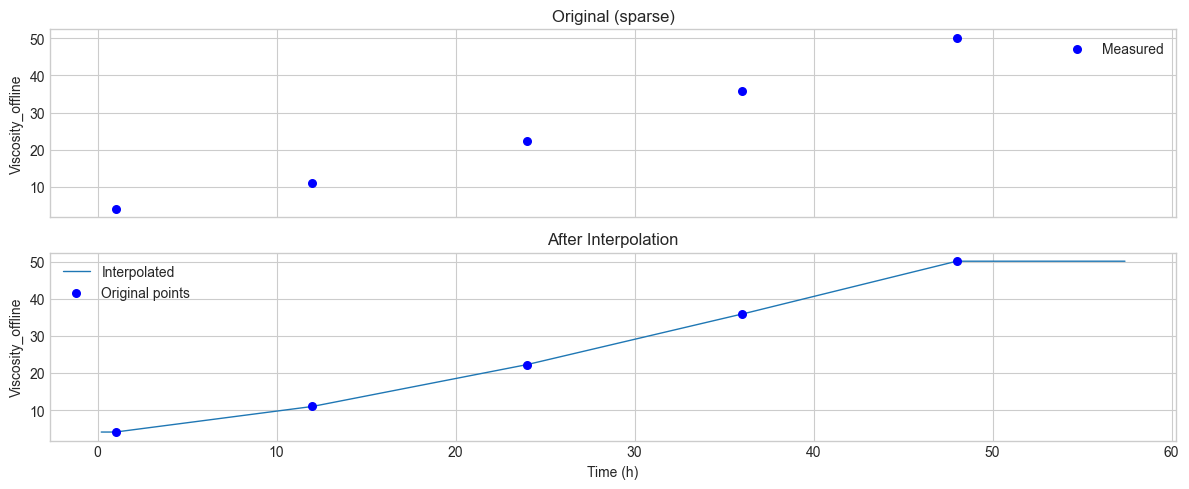

Original NaN count: 282
Interpolated NaN count: 0


In [8]:
# Show before/after interpolation for a sparse feature
feat = "Viscosity_offline"
if feat in df.columns:
    early = extract_early_window(df, 0.25)
    
    original = early[feat].copy()
    interpolated = interpolate_sparse_feature(original)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    
    # Original
    ax = axes[0]
    mask = original.notna()
    ax.scatter(early.loc[mask, "time"], original[mask], s=30, c="blue", label="Measured")
    ax.set_ylabel(feat)
    ax.set_title("Original (sparse)")
    ax.legend()
    
    # Interpolated
    ax = axes[1]
    ax.plot(early["time"], interpolated, linewidth=1, label="Interpolated")
    ax.scatter(early.loc[mask, "time"], original[mask], s=30, c="blue", zorder=5, label="Original points")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(feat)
    ax.set_title("After Interpolation")
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Original NaN count: {original.isna().sum()}")
    print(f"Interpolated NaN count: {interpolated.isna().sum()}")

## 4. Smoothing Effects

Compare raw vs smoothed signals for noisy features.

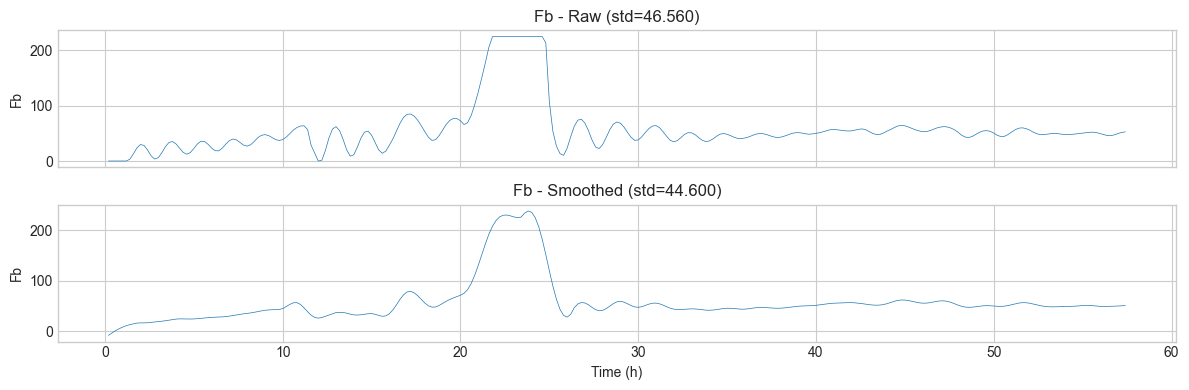

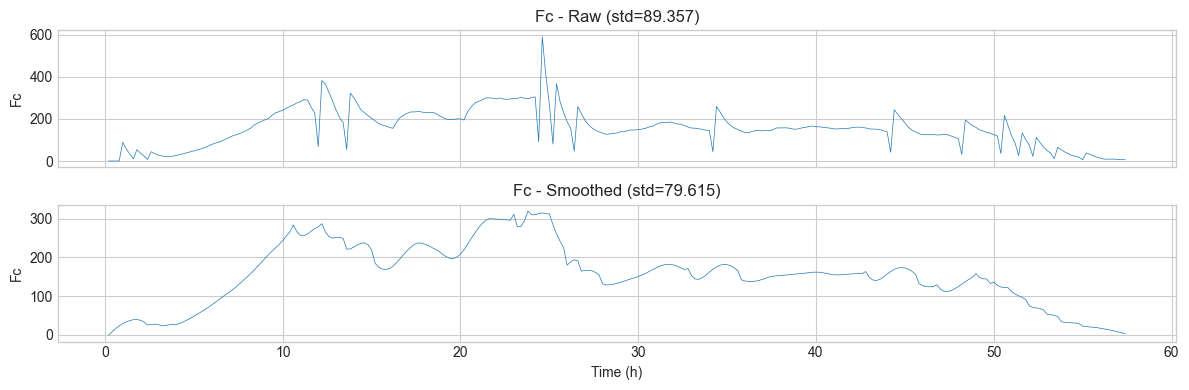

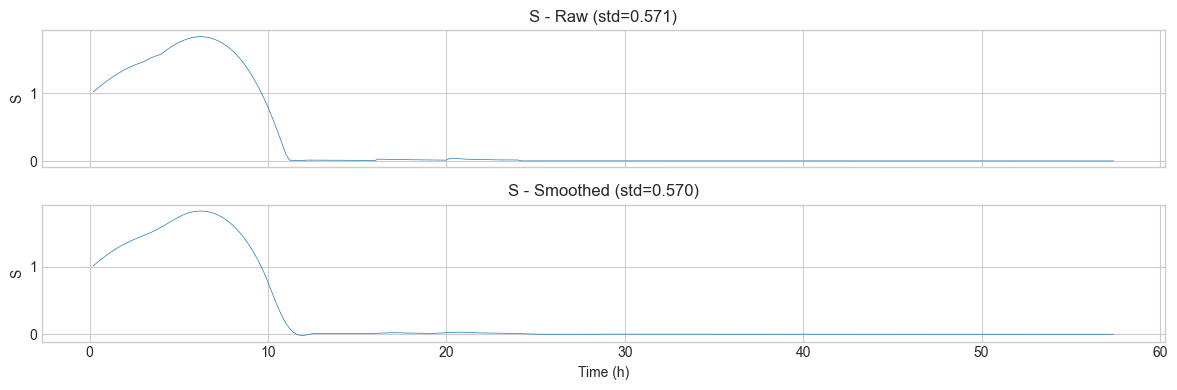

In [9]:
# Compare smoothing on noisy features
noisy_features = NOISY_TREND_FEATURES + NOISY_SHORT_TREND_FEATURES
available_noisy = [f for f in noisy_features if f in df.columns]

if available_noisy:
    early = extract_early_window(df, 0.25)
    
    # Process with and without smoothing
    raw = preprocess_expanded_features(early, available_noisy, apply_smoothing=False)
    smoothed = preprocess_expanded_features(early, available_noisy, apply_smoothing=True)
    
    # Plot comparison for first 3 features
    for feat in available_noisy[:3]:
        fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
        
        axes[0].plot(early["time"], raw[feat], linewidth=0.5)
        axes[0].set_ylabel(feat)
        axes[0].set_title(f"{feat} - Raw (std={raw[feat].std():.3f})")
        
        axes[1].plot(early["time"], smoothed[feat], linewidth=0.5)
        axes[1].set_ylabel(feat)
        axes[1].set_title(f"{feat} - Smoothed (std={smoothed[feat].std():.3f})")
        axes[1].set_xlabel("Time (h)")
        
        plt.tight_layout()
        plt.show()

## 5. Normalization Statistics

Compute and display normalization stats for the expanded feature set.

In [10]:
# Compute stats from source domain
stats = compute_normalization_stats_expanded(
    batches,
    splits["source"],
    INPUT_FEATURES_EXPANDED,
    window_fraction=0.25,
    apply_smoothing=False,
)

print(f"Features available: {len(stats['features'])}")
print(f"\nFeatures by signal type:")
for feat in stats["features"]:
    print(f"  {feat}: {stats['signal_types'][feat]}")

Features available: 25

Features by signal type:
  Fg: step_wise
  Fs: step_wise
  Fw: step_wise
  pressure: step_wise
  Fpaa: step_wise
  Foil: step_wise
  Fa: spiky_sparse
  Fh: spiky_sparse
  Fremoved: spiky_sparse
  Fb: noisy_trend
  Fc: noisy_trend
  S: noisy_trend
  OUR: noisy_trend
  O2: noisy_trend
  pH: noisy_short_trend
  T: noisy_short_trend
  DO2: trend_jump
  V: trend_jump
  Wt: trend_jump
  CO2outgas: trend_jump
  CER: trend_jump
  PAA_offline: sparse_offline
  NH3_offline: sparse_offline
  X_offline: sparse_offline
  Viscosity_offline: sparse_offline


In [11]:
# Display scaling parameters
scaling_df = pd.DataFrame([
    {
        "feature": feat,
        "signal_type": stats["signal_types"][feat],
        "method": stats["scaling"][feat]["method"],
        "center": stats["scaling"][feat].get("mean", stats["scaling"][feat].get("median")),
        "scale": stats["scaling"][feat].get("std", stats["scaling"][feat].get("iqr")),
    }
    for feat in stats["features"]
])

print("Normalization parameters:")
display(scaling_df)

Normalization parameters:


,feature,signal_type,method,center,scale
0,Fg,step_wise,zscore,50.267242,10.398120
1,Fs,step_wise,zscore,49.831369,33.979423
2,Fw,step_wise,zscore,66.227098,169.491948
3,pressure,step_wise,zscore,0.841977,0.194573
4,Fpaa,step_wise,zscore,3.435640,4.512722
5,Foil,step_wise,zscore,32.957988,3.619440
6,Fa,spiky_sparse,robust,0.000000,1.000000
7,Fh,spiky_sparse,robust,0.000100,0.001126
8,Fremoved,spiky_sparse,robust,0.000000,1.000000
9,Fb,noisy_trend,zscore,65.584784,49.839223


## 6. Domain Comparison

Compare feature distributions between source and target domains.

In [12]:
# Collect source and target data
def collect_domain_data(batch_ids, features):
    data = []
    for batch_id in batch_ids:
        df = batches[batch_id]
        early = extract_early_window(df, 0.25)
        processed = preprocess_expanded_features(early, features)
        available = [f for f in features if f in processed.columns]
        data.append(processed[available])
    return pd.concat(data, ignore_index=True)

# Get available features
available_features = stats["features"]

source_data = collect_domain_data(splits["source"], available_features)
target_data = collect_domain_data(splits["target"], available_features)

print(f"Source samples: {len(source_data)}")
print(f"Target samples: {len(target_data)}")

Source samples: 8569
Target samples: 8412


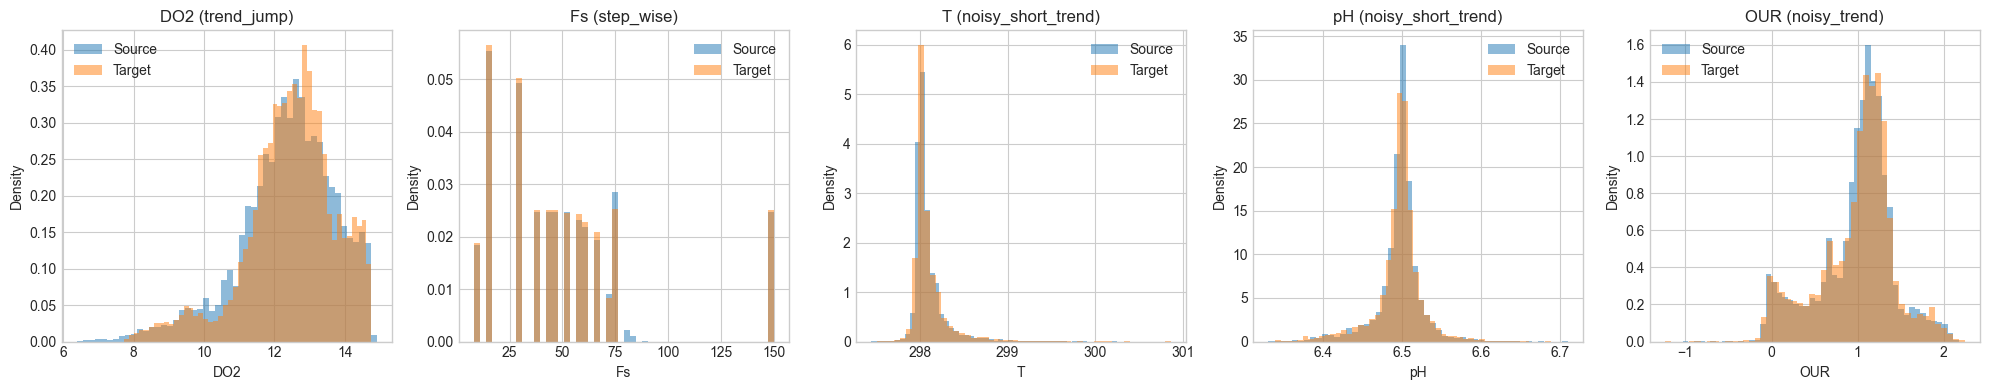

In [13]:
# Compare distributions for selected features
compare_features = ["DO2", "Fs", "T", "pH", "OUR"]
compare_features = [f for f in compare_features if f in available_features]

fig, axes = plt.subplots(1, len(compare_features), figsize=(4 * len(compare_features), 4))
if len(compare_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, compare_features):
    ax.hist(source_data[feat].dropna(), bins=50, alpha=0.5, label="Source", density=True)
    ax.hist(target_data[feat].dropna(), bins=50, alpha=0.5, label="Target", density=True)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title(f"{feat} ({get_signal_type(feat)})")

plt.tight_layout()
plt.show()

In [14]:
# Compute domain shift statistics (mean/std difference)
shift_stats = []

for feat in available_features:
    src_mean = source_data[feat].mean()
    src_std = source_data[feat].std()
    tgt_mean = target_data[feat].mean()
    tgt_std = target_data[feat].std()
    
    # Normalized shift (effect size)
    pooled_std = np.sqrt((src_std**2 + tgt_std**2) / 2)
    effect_size = abs(src_mean - tgt_mean) / pooled_std if pooled_std > 0 else 0
    
    shift_stats.append({
        "feature": feat,
        "signal_type": get_signal_type(feat),
        "source_mean": src_mean,
        "target_mean": tgt_mean,
        "effect_size": effect_size,
    })

shift_df = pd.DataFrame(shift_stats).sort_values("effect_size", ascending=False)
print("Domain shift by feature (Cohen's d effect size):")
display(shift_df.head(15))

Domain shift by feature (Cohen's d effect size):


,feature,signal_type,source_mean,target_mean,effect_size
22,NH3_offline,sparse_offline,1785.048996,1856.354541,1.003279
21,PAA_offline,sparse_offline,1057.441853,1295.261501,0.961544
9,Fb,noisy_trend,65.584784,72.361892,0.128957
4,Fpaa,step_wise,3.435640,3.909283,0.125067
16,DO2,trend_jump,12.369107,12.464213,0.071446
17,V,trend_jump,60614.499241,60451.903233,0.064635
10,Fc,noisy_trend,153.942563,161.753141,0.064068
2,Fw,step_wise,66.227098,57.299097,0.054284
15,T,noisy_short_trend,298.091118,298.099602,0.042406
3,pressure,step_wise,0.841977,0.837161,0.024840


## 7. Logistic Growth Model for Penicillin Concentration

Penicillin production follows a sigmoidal growth pattern. We fit a logistic function to each batch:

$$P(t) = \frac{K}{1 + e^{-r(t - t_0)}}$$

Where:
- **K** = carrying capacity (maximum penicillin concentration)
- **r** = growth rate
- **t₀** = inflection point (time at half-maximum)

This analysis examines:
1. How well the logistic model fits individual batches
2. Whether fitted parameters differ systematically by control mode

In [15]:
from scipy.optimize import curve_fit
from scipy.stats import f_oneway, kruskal

def logistic_growth(t, K, r, t0):
    """Logistic growth function for penicillin concentration."""
    return K / (1 + np.exp(-r * (t - t0)))


def logistic_with_lag(t, K, r, t0, lam):
    """Logistic with lag phase - guarantees P(0) = 0.

    Parameters:
        K: carrying capacity (max concentration)
        r: growth rate
        t0: inflection point
        lam: lag rate (higher = shorter lag phase)
    """
    logistic = K / (1 + np.exp(-r * (t - t0)))
    lag_factor = 1 - np.exp(-lam * t)
    return logistic * lag_factor


def logistic_with_delay(t, K, r, t0, t_lag):
    """Piecewise logistic with explicit delay period.

    P(t) = 0 for t < t_lag
    P(t) = logistic(t - t_lag) for t >= t_lag

    Parameters:
        K: carrying capacity (max concentration)
        r: growth rate
        t0: inflection point (relative to t_lag)
        t_lag: delay duration where P = 0
    """
    t = np.asarray(t)
    result = np.zeros_like(t, dtype=float)
    mask = t >= t_lag
    tau = t[mask] - t_lag
    result[mask] = K / (1 + np.exp(-r * (tau - t0)))
    return result


def logistic_with_delay_and_lag(t, K, r, t0, lam, t_lag):
    """Piecewise logistic with delay AND lag multiplier.

    P(t) = 0 for t < t_lag
    P(t) = logistic(t - t_lag) * lag_factor(t - t_lag) for t >= t_lag

    Parameters:
        K: carrying capacity (max concentration)
        r: growth rate
        t0: inflection point (relative to t_lag)
        lam: lag rate (higher = shorter lag phase)
        t_lag: delay duration where P = 0
    """
    t = np.asarray(t)
    result = np.zeros_like(t, dtype=float)
    mask = t >= t_lag
    tau = t[mask] - t_lag
    logistic = K / (1 + np.exp(-r * (tau - t0)))
    lag_factor = 1 - np.exp(-lam * tau)
    result[mask] = logistic * lag_factor
    return result




def logistic_with_decline(t, K, r, t0, lam, t_lag, t_break, slope):
    """Three-phase model: delay -> growth -> decline.
    
    Phase 1: P(t) = 0 for t < t_lag
    Phase 2: P(t) = logistic_with_lag(t - t_lag) for t_lag <= t < t_break
    Phase 3: P(t) = P(t_break) - slope * (t - t_break) for t >= t_break
    
    Parameters:
        K: carrying capacity (max concentration)
        r: growth rate
        t0: inflection point (relative to t_lag)
        lam: lag rate (higher = shorter lag phase)
        t_lag: delay duration where P = 0
        t_break: onset of decline phase
        slope: rate of linear decline (positive value)
    """
    t = np.asarray(t)
    result = np.zeros_like(t, dtype=float)
    
    # Phase 2: Growth (t_lag <= t < t_break)
    growth_mask = (t >= t_lag) & (t < t_break)
    if np.any(growth_mask):
        tau = t[growth_mask] - t_lag
        logistic = K / (1 + np.exp(-r * (tau - t0)))
        lag_factor = 1 - np.exp(-lam * tau)
        result[growth_mask] = logistic * lag_factor
    
    # Phase 3: Decline (t >= t_break)
    decline_mask = t >= t_break
    if np.any(decline_mask):
        # Compute P at breakpoint for continuity
        tau_break = t_break - t_lag
        P_at_break = K / (1 + np.exp(-r * (tau_break - t0))) * (1 - np.exp(-lam * tau_break))
        result[decline_mask] = P_at_break - slope * (t[decline_mask] - t_break)
        result[result < 0] = 0  # Floor at zero
    
    return result
def fit_logistic_batch(df, target_col="P"):
    """Fit logistic growth model to a single batch."""
    t = df["time"].values
    y = df[target_col].values

    # Remove NaN values
    mask = ~np.isnan(y)
    t, y = t[mask], y[mask]

    if len(t) < 10:
        return None

    # Initial parameter estimates
    K0 = y.max() * 1.1  # slightly above max observed
    t0_init = t[np.argmax(np.gradient(y))]  # time of max growth rate
    r0 = 0.1  # reasonable starting point

    try:
        popt, pcov = curve_fit(
            logistic_growth, t, y,
            p0=[K0, r0, t0_init],
            bounds=([0, 0.001, 0], [100, 2, t.max()]),
            maxfev=5000,
        )

        # Compute R² for goodness of fit
        y_pred = logistic_growth(t, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        return {
            "K": popt[0],
            "r": popt[1],
            "t0": popt[2],
            "r_squared": r_squared,
            "final_P": y[-1],
        }
    except (RuntimeError, ValueError):
        return None


def fit_logistic_with_lag_batch(df, target_col="P"):
    """Fit lag-adjusted logistic model to a single batch."""
    t = df["time"].values
    y = df[target_col].values

    # Remove NaN values
    mask = ~np.isnan(y)
    t, y = t[mask], y[mask]

    if len(t) < 10:
        return None

    # Initial parameter estimates
    K0 = y.max() * 1.1
    t0_init = t[np.argmax(np.gradient(y))]
    r0 = 0.1
    lam0 = 0.1  # lag rate initial guess

    try:
        popt, pcov = curve_fit(
            logistic_with_lag, t, y,
            p0=[K0, r0, t0_init, lam0],
            bounds=([0, 0.001, 0, 0.001], [100, 2, t.max(), 2]),
            maxfev=10000,
        )

        # Compute R² for goodness of fit
        y_pred = logistic_with_lag(t, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        return {
            "K": popt[0],
            "r": popt[1],
            "t0": popt[2],
            "lam": popt[3],
            "r_squared": r_squared,
            "final_P": y[-1],
        }
    except (RuntimeError, ValueError):
        return None


def fit_logistic_with_delay_batch(df, target_col="P"):
    """Fit delay + standard logistic model to a single batch."""
    t = df["time"].values
    y = df[target_col].values

    # Remove NaN values
    mask = ~np.isnan(y)
    t, y = t[mask], y[mask]

    if len(t) < 10:
        return None

    # Estimate t_lag from first significant P value
    threshold = 0.01 * y.max()
    first_significant = np.where(y > threshold)[0]
    t_lag_init = t[first_significant[0]] if len(first_significant) > 0 else 10.0
    t_lag_init = max(0.1, min(t_lag_init, t.max() * 0.3))

    # Initial parameter estimates
    K0 = y.max() * 1.1
    t0_init = t[np.argmax(np.gradient(y))] - t_lag_init
    t0_init = max(10, t0_init)
    r0 = 0.1

    try:
        popt, pcov = curve_fit(
            logistic_with_delay, t, y,
            p0=[K0, r0, t0_init, t_lag_init],
            bounds=([0, 0.001, 0, 0], [100, 2, t.max(), t.max() * 0.5]),
            maxfev=10000,
        )

        # Compute R² for goodness of fit
        y_pred = logistic_with_delay(t, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        return {
            "K": popt[0],
            "r": popt[1],
            "t0": popt[2],
            "t_lag": popt[3],
            "r_squared": r_squared,
            "final_P": y[-1],
        }
    except (RuntimeError, ValueError):
        return None


def fit_logistic_with_delay_and_lag_batch(df, target_col="P"):
    """Fit delay + lag-adjusted logistic model to a single batch."""
    t = df["time"].values
    y = df[target_col].values

    # Remove NaN values
    mask = ~np.isnan(y)
    t, y = t[mask], y[mask]

    if len(t) < 10:
        return None

    # Estimate t_lag from first significant P value
    threshold = 0.01 * y.max()
    first_significant = np.where(y > threshold)[0]
    t_lag_init = t[first_significant[0]] if len(first_significant) > 0 else 10.0
    t_lag_init = max(0.1, min(t_lag_init, t.max() * 0.3))

    # Initial parameter estimates
    K0 = y.max() * 1.1
    t0_init = t[np.argmax(np.gradient(y))] - t_lag_init
    t0_init = max(10, t0_init)
    r0 = 0.1
    lam0 = 0.1

    try:
        popt, pcov = curve_fit(
            logistic_with_delay_and_lag, t, y,
            p0=[K0, r0, t0_init, lam0, t_lag_init],
            bounds=([0, 0.001, 0, 0.001, 0], [100, 2, t.max(), 2, t.max() * 0.5]),
            maxfev=10000,
        )

        # Compute R² for goodness of fit
        y_pred = logistic_with_delay_and_lag(t, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        return {
            "K": popt[0],
            "r": popt[1],
            "t0": popt[2],
            "lam": popt[3],
            "t_lag": popt[4],
            "r_squared": r_squared,
            "final_P": y[-1],
        }
    except (RuntimeError, ValueError):
        return None




def fit_logistic_with_decline_batch(df, target_col="P"):
    """Fit three-phase model (delay -> growth -> decline) to a single batch.
    
    This model extends delay+lag logistic with an optional decline phase.
    For batches without decline, the optimizer will converge to slope -> 0.
    """
    t = df["time"].values
    y = df[target_col].values
    
    # Remove NaN values
    mask = ~np.isnan(y)
    t, y = t[mask], y[mask]
    
    if len(t) < 10:
        return None
    
    # Estimate t_lag from first significant P value
    threshold = 0.01 * y.max()
    first_significant = np.where(y > threshold)[0]
    t_lag_init = t[first_significant[0]] if len(first_significant) > 0 else 10.0
    t_lag_init = max(0.1, min(t_lag_init, t.max() * 0.3))
    
    # Initial parameter estimates
    K0 = y.max() * 1.1
    t0_init = t[np.argmax(np.gradient(y))] - t_lag_init
    t0_init = max(10, t0_init)
    r0 = 0.1
    lam0 = 0.1
    
    # Decline estimates: time of peak, late-stage slope
    t_break_init = t[np.argmax(y)]
    # Ensure t_break_init is within bounds
    t_break_init = max(t.max() * 0.5, min(t_break_init, t.max() - 1))
    
    # Estimate late-stage slope from last 30% of data
    late_idx = int(len(y) * 0.7)
    if late_idx < len(y) - 1:
        late_slope_fit = np.polyfit(t[late_idx:], y[late_idx:], 1)
        slope_init = max(0.01, -late_slope_fit[0]) if late_slope_fit[0] < 0 else 0.01
    else:
        slope_init = 0.01
    
    p0 = [K0, r0, t0_init, lam0, t_lag_init, t_break_init, slope_init]
    bounds = (
        [0, 0.001, 0, 0.001, 0, t.max() * 0.5, 0],  # lower bounds
        [100, 2, t.max(), 2, t.max() * 0.3, t.max(), 2]  # upper bounds
    )
    
    try:
        popt, pcov = curve_fit(
            logistic_with_decline, t, y,
            p0=p0,
            bounds=bounds,
            maxfev=10000,
        )
        
        # Compute R² for goodness of fit
        y_pred = logistic_with_decline(t, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Determine if decline phase is active
        has_decline = popt[6] > 0.02  # slope > 0.02 indicates meaningful decline
        
        return {
            "K": popt[0],
            "r": popt[1],
            "t0": popt[2],
            "lam": popt[3],
            "t_lag": popt[4],
            "t_break": popt[5],
            "slope": popt[6],
            "has_decline": has_decline,
            "r_squared": r_squared,
            "final_P": y[-1],
        }
    except (RuntimeError, ValueError):
        return None
def get_control_mode(batch_id):
    """Map batch ID to control mode."""
    if 1 <= batch_id <= 30:
        return "Recipe"
    elif 31 <= batch_id <= 60:
        return "Operator"
    elif 61 <= batch_id <= 90:
        return "APC"
    else:
        return "Fault"

# Fit logistic model to all non-fault batches
fit_results = []

for batch_id in range(1, 91):  # Exclude fault batches 91-100
    df = batches[batch_id]
    result = fit_logistic_batch(df)

    if result is not None:
        result["batch_id"] = batch_id
        result["control_mode"] = get_control_mode(batch_id)
        fit_results.append(result)

fit_df = pd.DataFrame(fit_results)
print(f"Successfully fitted {len(fit_df)} / 90 batches")
print(f"\nFit quality summary (R²):")
print(fit_df["r_squared"].describe())

Successfully fitted 90 / 90 batches

Fit quality summary (R²):
count    90.000000
mean      0.974303
std       0.038092
min       0.772283
25%       0.979772
50%       0.989842
75%       0.992178
max       0.994578
Name: r_squared, dtype: float64


In [16]:
# Identify good and bad fits based on R²
fit_df_sorted = fit_df.sort_values("r_squared", ascending=False)

print("Fit Quality Distribution:")
print(f"  Best R²:  {fit_df['r_squared'].max():.6f} (Batch {fit_df.loc[fit_df['r_squared'].idxmax(), 'batch_id']})")
print(f"  Worst R²: {fit_df['r_squared'].min():.6f} (Batch {fit_df.loc[fit_df['r_squared'].idxmin(), 'batch_id']})")
print(f"  Median R²: {fit_df['r_squared'].median():.6f}")

print("\nTop 5 best fits:")
display(fit_df_sorted[["batch_id", "control_mode", "r_squared", "K", "r", "t0"]].head())

print("\nBottom 5 worst fits:")
display(fit_df_sorted[["batch_id", "control_mode", "r_squared", "K", "r", "t0"]].tail())

Fit Quality Distribution:
  Best R²:  0.994578 (Batch 7)
  Worst R²: 0.772283 (Batch 45)
  Median R²: 0.989842

Top 5 best fits:


,batch_id,control_mode,r_squared,K,r,t0
6,7,Recipe,0.994578,29.080510,0.036961,92.699827
30,31,Operator,0.994323,34.101350,0.031883,107.055281
4,5,Recipe,0.994144,27.877235,0.037673,97.420080
68,69,APC,0.994105,27.629901,0.032598,104.008278
14,15,Recipe,0.993879,28.154991,0.036885,98.758522



Bottom 5 worst fits:


,batch_id,control_mode,r_squared,K,r,t0
29,30,Recipe,0.894575,14.086804,0.077885,64.153799
32,33,Operator,0.890383,19.366374,0.059578,75.100482
24,25,Recipe,0.887321,17.793005,0.059010,78.294279
8,9,Recipe,0.811185,11.029228,0.093063,62.739118
44,45,Operator,0.772283,9.933396,0.094068,57.581621


### Good vs Bad Logistic Fits

Below we compare batches where the logistic model fits well versus poorly. Understanding failure modes helps identify when the simple logistic assumption breaks down.

/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/2368905140.py:69: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/2368905140.py:69: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/2368905140.py:70: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig("../outputs/figures/logistic_fit_good_vs_bad.png", dpi=150)
/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/2368905140.py:70: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig("../outputs/figures/logistic_fit_good_vs_bad.png", dpi=150)
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas

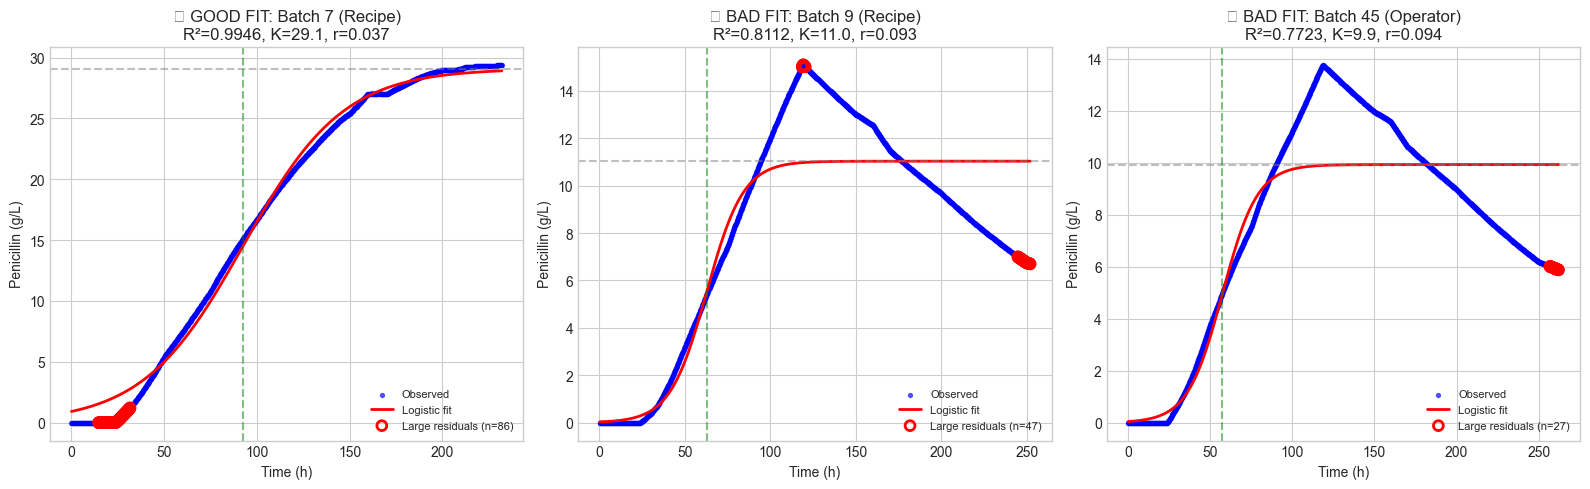


ANALYSIS OF FIT QUALITY

✓ GOOD FIT (Batch 7):
  - R² = 0.994578 (explains 99.46% of variance)
  - Max residual: 2.13 g/L
  - The logistic curve closely follows the observed sigmoidal growth pattern

✗ BAD FIT (Batch 9):
  - R² = 0.811185 (explains only 81.12% of variance)
  - Max residual: 4.33 g/L

✗ BAD FIT (Batch 45):
  - R² = 0.772283 (explains only 77.23% of variance)
  - Max residual: 4.05 g/L


In [17]:
# Select one good fit and two bad fits for detailed comparison
# Good fit: highest R²
best_batch_id = int(fit_df.loc[fit_df['r_squared'].idxmax(), 'batch_id'])

# Bad fits: two lowest R² values
worst_batch_ids = fit_df_sorted.tail(2)["batch_id"].tolist()

# Create detailed comparison plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_fit_with_residuals(ax, batch_id, fit_row, title_prefix=""):
    """Plot observed vs fitted with residual analysis."""
    df = batches[batch_id]
    t = df["time"].values
    y = df["P"].values
    
    # Remove NaN
    mask = ~np.isnan(y)
    t_clean, y_clean = t[mask], y[mask]
    
    # Compute fit
    y_fit = logistic_growth(t_clean, fit_row["K"], fit_row["r"], fit_row["t0"])
    residuals = y_clean - y_fit
    
    # Plot observed data
    ax.scatter(t_clean, y_clean, s=8, alpha=0.6, c="blue", label="Observed")
    
    # Plot fitted curve
    t_smooth = np.linspace(t_clean.min(), t_clean.max(), 200)
    y_fit_smooth = logistic_growth(t_smooth, fit_row["K"], fit_row["r"], fit_row["t0"])
    ax.plot(t_smooth, y_fit_smooth, "r-", linewidth=2, label="Logistic fit")
    
    # Mark key parameters
    ax.axhline(fit_row["K"], color="gray", linestyle="--", alpha=0.5)
    ax.axvline(fit_row["t0"], color="green", linestyle="--", alpha=0.5)
    
    # Highlight regions of poor fit (large residuals)
    large_residual_mask = np.abs(residuals) > 2 * np.std(residuals)
    if large_residual_mask.any():
        ax.scatter(t_clean[large_residual_mask], y_clean[large_residual_mask], 
                   s=50, facecolors='none', edgecolors='red', linewidths=2, 
                   label=f"Large residuals (n={large_residual_mask.sum()})")
    
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Penicillin (g/L)")
    ax.set_title(f"{title_prefix}Batch {batch_id} ({fit_row['control_mode']})\n"
                 f"R²={fit_row['r_squared']:.4f}, K={fit_row['K']:.1f}, r={fit_row['r']:.3f}")
    ax.legend(loc="lower right", fontsize=8)
    
    return residuals, t_clean, y_clean, y_fit

# Plot good fit
good_row = fit_df[fit_df["batch_id"] == best_batch_id].iloc[0]
res_good, t_good, y_good, yfit_good = plot_fit_with_residuals(
    axes[0], best_batch_id, good_row, title_prefix="✓ GOOD FIT: "
)

# Plot bad fits
bad_row_1 = fit_df[fit_df["batch_id"] == worst_batch_ids[0]].iloc[0]
res_bad1, t_bad1, y_bad1, yfit_bad1 = plot_fit_with_residuals(
    axes[1], worst_batch_ids[0], bad_row_1, title_prefix="✗ BAD FIT: "
)

bad_row_2 = fit_df[fit_df["batch_id"] == worst_batch_ids[1]].iloc[0]
res_bad2, t_bad2, y_bad2, yfit_bad2 = plot_fit_with_residuals(
    axes[2], worst_batch_ids[1], bad_row_2, title_prefix="✗ BAD FIT: "
)

plt.tight_layout()
plt.savefig("../outputs/figures/logistic_fit_good_vs_bad.png", dpi=150)
plt.show()

# Print analysis of why fits are bad
print("\n" + "="*70)
print("ANALYSIS OF FIT QUALITY")
print("="*70)

print(f"\n✓ GOOD FIT (Batch {best_batch_id}):")
print(f"  - R² = {good_row['r_squared']:.6f} (explains {good_row['r_squared']*100:.2f}% of variance)")
print(f"  - Max residual: {np.abs(res_good).max():.2f} g/L")
print(f"  - The logistic curve closely follows the observed sigmoidal growth pattern")

print(f"\n✗ BAD FIT (Batch {worst_batch_ids[0]}):")
print(f"  - R² = {bad_row_1['r_squared']:.6f} (explains only {bad_row_1['r_squared']*100:.2f}% of variance)")
print(f"  - Max residual: {np.abs(res_bad1).max():.2f} g/L")

print(f"\n✗ BAD FIT (Batch {worst_batch_ids[1]}):")
print(f"  - R² = {bad_row_2['r_squared']:.6f} (explains only {bad_row_2['r_squared']*100:.2f}% of variance)")
print(f"  - Max residual: {np.abs(res_bad2).max():.2f} g/L")

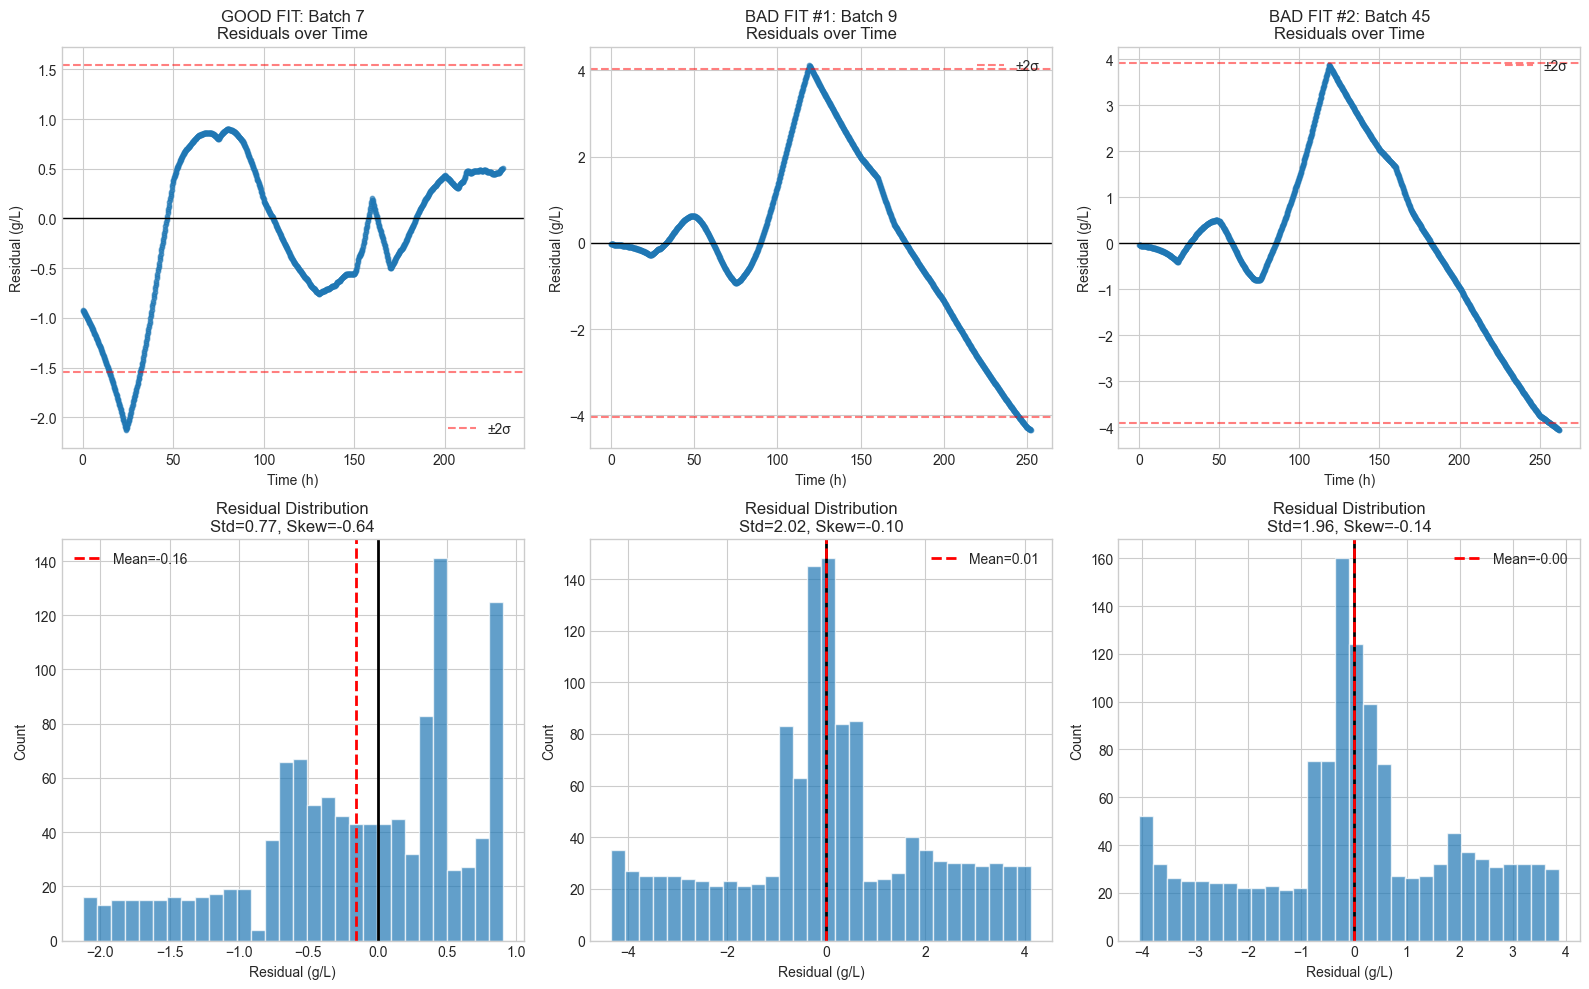


FAILURE MODE ANALYSIS

GOOD FIT (Batch 7):
  ⚠ Heteroscedasticity: fit is worse in early phase
      Early std: 0.99, Late std: 0.44
  ⚠ Autocorrelation: only 6 runs vs 580 expected
      → Model misses systematic curvature in the data

BAD FIT #1 (Batch 9):
  ⚠ Autocorrelation: only 5 runs vs 630 expected
      → Model misses systematic curvature in the data

BAD FIT #2 (Batch 45):
  ⚠ Autocorrelation: only 5 runs vs 655 expected
      → Model misses systematic curvature in the data


In [18]:
# Detailed residual analysis showing WHERE fits fail
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

batch_ids = [best_batch_id, worst_batch_ids[0], worst_batch_ids[1]]
titles = ["GOOD FIT", "BAD FIT #1", "BAD FIT #2"]
rows = [good_row, bad_row_1, bad_row_2]
residuals_list = [res_good, res_bad1, res_bad2]
t_list = [t_good, t_bad1, t_bad2]

for col, (batch_id, title, fit_row, residuals, t_vals) in enumerate(
    zip(batch_ids, titles, rows, residuals_list, t_list)
):
    # Top row: Residuals over time
    ax = axes[0, col]
    ax.scatter(t_vals, residuals, s=10, alpha=0.6)
    ax.axhline(0, color="black", linestyle="-", linewidth=1)
    ax.axhline(2*np.std(residuals), color="red", linestyle="--", alpha=0.5, label="±2σ")
    ax.axhline(-2*np.std(residuals), color="red", linestyle="--", alpha=0.5)
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Residual (g/L)")
    ax.set_title(f"{title}: Batch {batch_id}\nResiduals over Time")
    ax.legend()
    
    # Shade regions where model systematically over/under-predicts
    # Identify runs of same-sign residuals
    signs = np.sign(residuals)
    
    # Bottom row: Histogram of residuals
    ax = axes[1, col]
    ax.hist(residuals, bins=30, edgecolor="white", alpha=0.7)
    ax.axvline(0, color="black", linestyle="-", linewidth=2)
    ax.axvline(np.mean(residuals), color="red", linestyle="--", linewidth=2, 
               label=f"Mean={np.mean(residuals):.2f}")
    ax.set_xlabel("Residual (g/L)")
    ax.set_ylabel("Count")
    ax.set_title(f"Residual Distribution\nStd={np.std(residuals):.2f}, Skew={pd.Series(residuals).skew():.2f}")
    ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/logistic_fit_residuals.png", dpi=150)
plt.show()

# Identify specific failure modes
print("\n" + "="*70)
print("FAILURE MODE ANALYSIS")
print("="*70)

for batch_id, title, fit_row, residuals, t_vals in zip(
    batch_ids, titles, rows, residuals_list, t_list
):
    print(f"\n{title} (Batch {batch_id}):")
    
    # Check for systematic bias (mean residual far from 0)
    mean_res = np.mean(residuals)
    if abs(mean_res) > 0.5:
        print(f"  ⚠ Systematic bias: mean residual = {mean_res:.2f} g/L")
    
    # Check for heteroscedasticity (residual variance changes over time)
    mid_point = len(residuals) // 2
    early_std = np.std(residuals[:mid_point])
    late_std = np.std(residuals[mid_point:])
    if max(early_std, late_std) / min(early_std, late_std) > 2:
        worse_phase = "early" if early_std > late_std else "late"
        print(f"  ⚠ Heteroscedasticity: fit is worse in {worse_phase} phase")
        print(f"      Early std: {early_std:.2f}, Late std: {late_std:.2f}")
    
    # Check for autocorrelated residuals (runs of same sign)
    signs = np.sign(residuals)
    runs = np.sum(np.diff(signs) != 0) + 1
    expected_runs = len(residuals) / 2
    if runs < expected_runs * 0.5:
        print(f"  ⚠ Autocorrelation: only {runs} runs vs {expected_runs:.0f} expected")
        print(f"      → Model misses systematic curvature in the data")
    
    # Check for outliers
    outliers = np.sum(np.abs(residuals) > 3 * np.std(residuals))
    if outliers > 0:
        print(f"  ⚠ Outliers: {outliers} points exceed 3σ threshold")
    
    if abs(mean_res) <= 0.5 and runs >= expected_runs * 0.5 and outliers == 0:
        print(f"  ✓ No major issues detected - good logistic fit")

### Try a better Model: Logistic with Lag Phase

The standard logistic model cannot produce P(0) = 0, causing poor fits during the early **lag phase**. We use a modified model with a lag multiplier:

$$P(t) = \frac{K}{1 + e^{-r(t - t_0)}} \cdot (1 - e^{-\lambda t})$$

**Key property**: P(0) = 0 guaranteed, since $(1 - e^0) = 0$

**Parameters:**
- **K** = carrying capacity (max concentration)
- **r** = growth rate  
- **t₀** = inflection point
- **λ** = lag rate (higher = shorter lag phase)

In [19]:
# Fit lag-adjusted model to all batches and compare with standard logistic
lag_fit_results = []

for batch_id in range(1, 91):
    df = batches[batch_id]
    result = fit_logistic_with_lag_batch(df)
    
    if result is not None:
        result["batch_id"] = batch_id
        result["control_mode"] = get_control_mode(batch_id)
        lag_fit_results.append(result)

lag_fit_df = pd.DataFrame(lag_fit_results)
print(f"Successfully fitted lag model to {len(lag_fit_df)} / 90 batches")
print(f"\nLag model fit quality summary (R²):")
print(lag_fit_df["r_squared"].describe())

Successfully fitted lag model to 90 / 90 batches

Lag model fit quality summary (R²):
count    90.000000
mean      0.979364
std       0.040300
min       0.772314
25%       0.980252
50%       0.998291
75%       0.998920
max       0.999424
Name: r_squared, dtype: float64


In [20]:
# Compare R² improvement: standard vs lag model
comparison_df = fit_df[["batch_id", "r_squared"]].merge(
    lag_fit_df[["batch_id", "r_squared"]], 
    on="batch_id", 
    suffixes=("_standard", "_lag")
)
comparison_df["r2_improvement"] = comparison_df["r_squared_lag"] - comparison_df["r_squared_standard"]

print("R² Comparison: Standard Logistic vs Lag-Adjusted Model")
print("=" * 60)
print(f"\nStandard Logistic:")
print(f"  Mean R²:   {comparison_df['r_squared_standard'].mean():.6f}")
print(f"  Min R²:    {comparison_df['r_squared_standard'].min():.6f}")

print(f"\nLag-Adjusted Model:")
print(f"  Mean R²:   {comparison_df['r_squared_lag'].mean():.6f}")
print(f"  Min R²:    {comparison_df['r_squared_lag'].min():.6f}")

print(f"\nImprovement:")
print(f"  Mean ΔR²:  {comparison_df['r2_improvement'].mean():.6f}")
print(f"  Max ΔR²:   {comparison_df['r2_improvement'].max():.6f}")

# Show batches with biggest improvements
print("\nTop 5 batches with largest R² improvement:")
top_improved = comparison_df.nlargest(5, "r2_improvement")
display(top_improved[["batch_id", "r_squared_standard", "r_squared_lag", "r2_improvement"]])

R² Comparison: Standard Logistic vs Lag-Adjusted Model

Standard Logistic:
  Mean R²:   0.974303
  Min R²:    0.772283

Lag-Adjusted Model:
  Mean R²:   0.979364
  Min R²:    0.772314

Improvement:
  Mean ΔR²:  0.005061
  Max ΔR²:   0.014245

Top 5 batches with largest R² improvement:


,batch_id,r_squared_standard,r_squared_lag,r2_improvement
11,12,0.985090,0.999335,0.014245
12,13,0.986848,0.999424,0.012576
63,64,0.987789,0.999198,0.011409
69,70,0.987562,0.998470,0.010909
80,81,0.988771,0.999178,0.010407


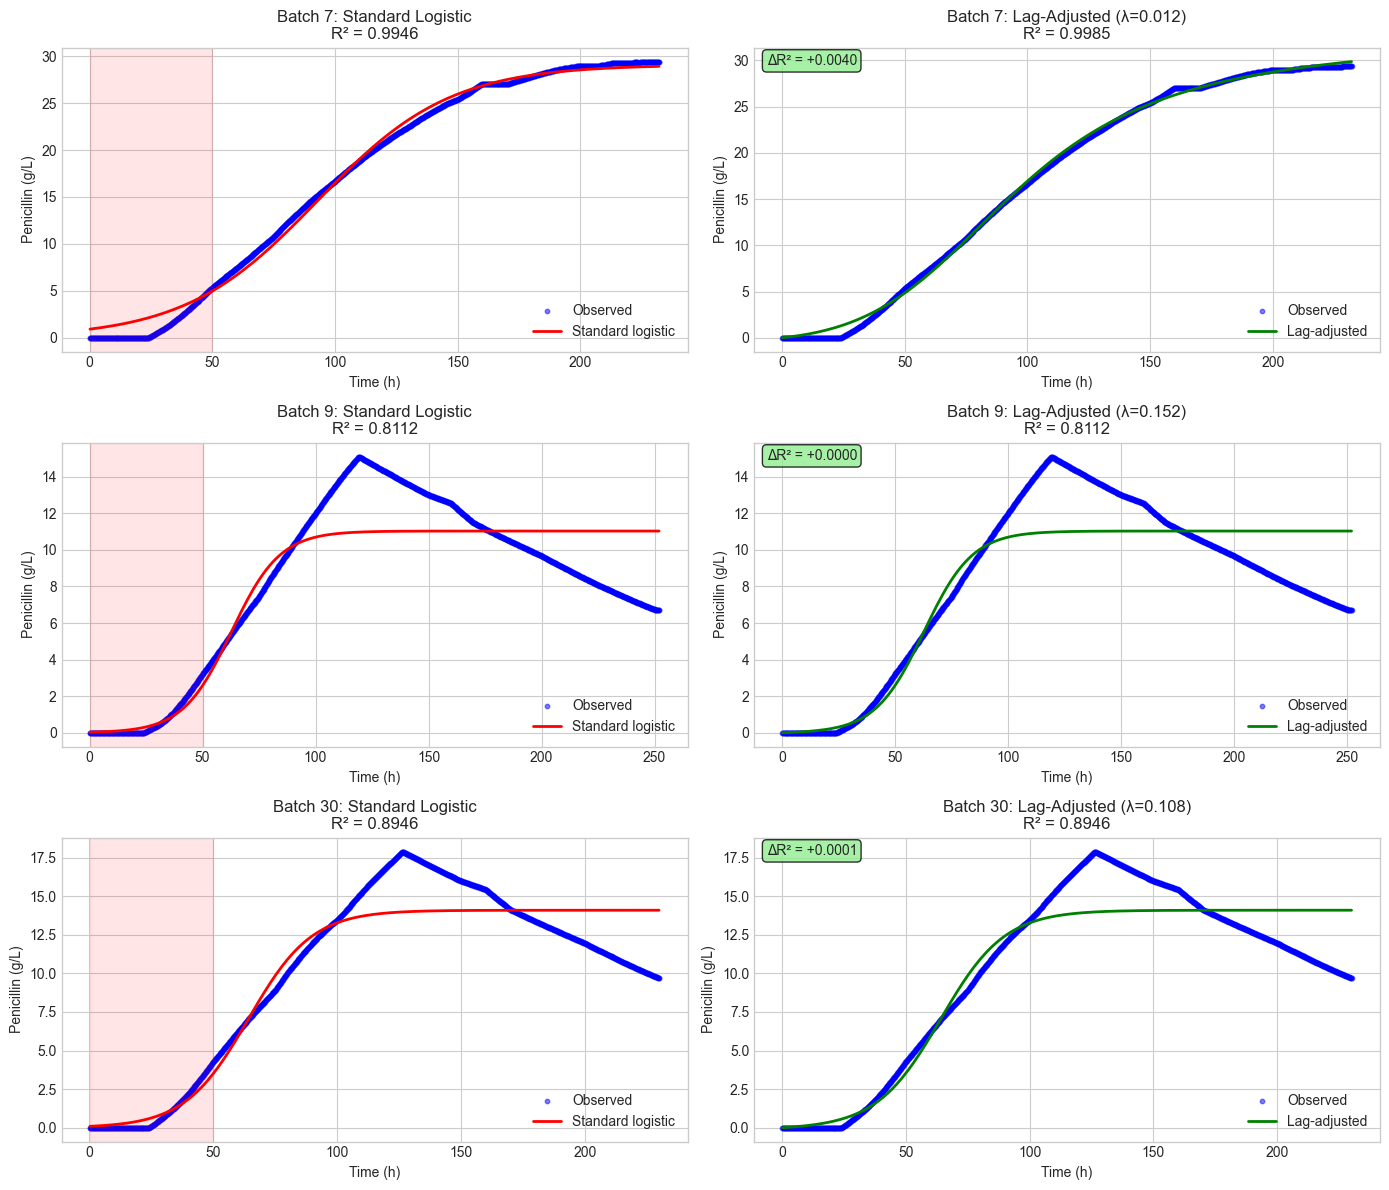


Key insight: The lag-adjusted model correctly forces P(0)=0,
eliminating the early overshoot that causes poor fits in the standard model.


In [21]:
# Visual comparison: Standard vs Lag model on worst-fitting batches
# Use batches 45 and 9 which had poorest standard logistic fits
compare_batch_ids = [7, 9, 30]

fig, axes = plt.subplots(len(compare_batch_ids), 2, figsize=(14, 4 * len(compare_batch_ids)))

for row, batch_id in enumerate(compare_batch_ids):
    df = batches[batch_id]
    t = df["time"].values
    y = df["P"].values
    mask = ~np.isnan(y)
    t_clean, y_clean = t[mask], y[mask]
    
    # Get fitted parameters
    std_row = fit_df[fit_df["batch_id"] == batch_id].iloc[0]
    lag_row = lag_fit_df[lag_fit_df["batch_id"] == batch_id].iloc[0]
    
    t_smooth = np.linspace(t_clean.min(), t_clean.max(), 200)
    
    # Left: Standard logistic
    ax = axes[row, 0]
    y_std = logistic_growth(t_smooth, std_row["K"], std_row["r"], std_row["t0"])
    ax.scatter(t_clean, y_clean, s=10, alpha=0.5, c="blue", label="Observed")
    ax.plot(t_smooth, y_std, "r-", linewidth=2, label="Standard logistic")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Penicillin (g/L)")
    ax.set_title(f"Batch {batch_id}: Standard Logistic\nR² = {std_row['r_squared']:.4f}")
    ax.legend(loc="lower right")
    
    # Highlight early phase where standard model overshoots
    early_mask = t_clean < 50
    if early_mask.any():
        ax.axvspan(t_clean.min(), 50, alpha=0.1, color="red", label="Lag phase")
    
    # Right: Lag-adjusted
    ax = axes[row, 1]
    y_lag = logistic_with_lag(t_smooth, lag_row["K"], lag_row["r"], lag_row["t0"], lag_row["lam"])
    ax.scatter(t_clean, y_clean, s=10, alpha=0.5, c="blue", label="Observed")
    ax.plot(t_smooth, y_lag, "g-", linewidth=2, label="Lag-adjusted")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("Penicillin (g/L)")
    ax.set_title(f"Batch {batch_id}: Lag-Adjusted (λ={lag_row['lam']:.3f})\nR² = {lag_row['r_squared']:.4f}")
    ax.legend(loc="lower right")
    
    # Highlight improvement
    r2_diff = lag_row["r_squared"] - std_row["r_squared"]
    ax.annotate(f"ΔR² = +{r2_diff:.4f}", xy=(0.02, 0.98), xycoords="axes fraction",
                fontsize=10, ha="left", va="top", 
                bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.8))

plt.tight_layout()
plt.savefig("../outputs/figures/logistic_standard_vs_lag.png", dpi=150)
plt.show()

print("\nKey insight: The lag-adjusted model correctly forces P(0)=0,")
print("eliminating the early overshoot that causes poor fits in the standard model.")

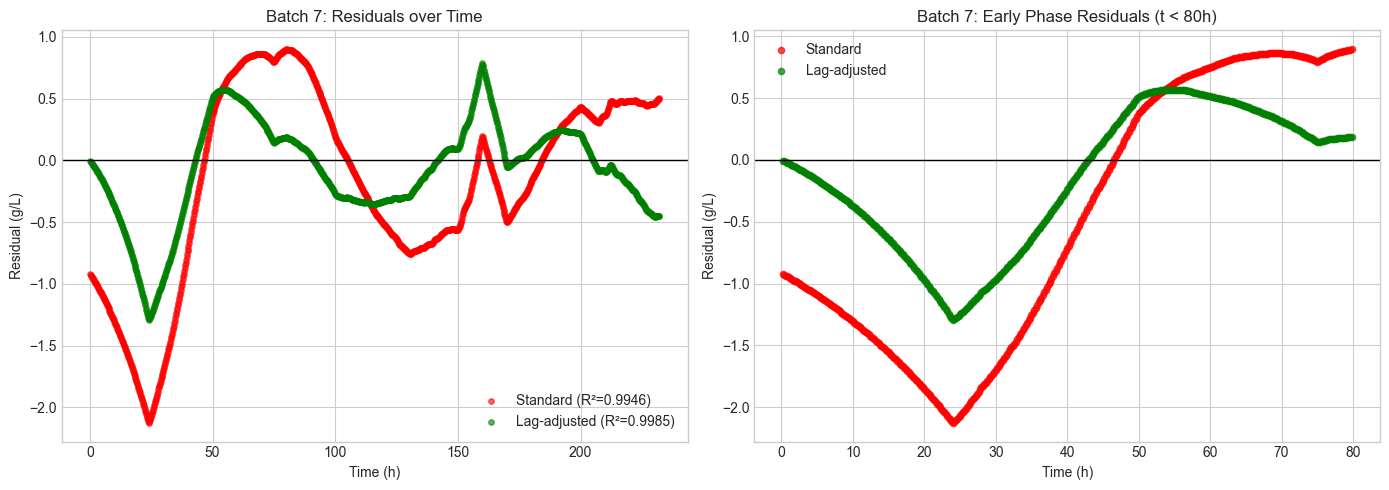


Batch 7 residual statistics:
  Standard logistic - Mean: -0.160, Std: 0.772
  Lag-adjusted      - Mean: -0.072, Std: 0.403


In [22]:
# Residual comparison for worst-fitting batch (45)
batch_id = 7
df = batches[batch_id]
t = df["time"].values
y = df["P"].values
mask = ~np.isnan(y)
t_clean, y_clean = t[mask], y[mask]

std_row = fit_df[fit_df["batch_id"] == batch_id].iloc[0]
lag_row = lag_fit_df[lag_fit_df["batch_id"] == batch_id].iloc[0]

y_std_pred = logistic_growth(t_clean, std_row["K"], std_row["r"], std_row["t0"])
y_lag_pred = logistic_with_lag(t_clean, lag_row["K"], lag_row["r"], lag_row["t0"], lag_row["lam"])

res_std = y_clean - y_std_pred
res_lag = y_clean - y_lag_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals over time
ax = axes[0]
ax.scatter(t_clean, res_std, s=15, alpha=0.6, c="red", label=f"Standard (R²={std_row['r_squared']:.4f})")
ax.scatter(t_clean, res_lag, s=15, alpha=0.6, c="green", label=f"Lag-adjusted (R²={lag_row['r_squared']:.4f})")
ax.axhline(0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Time (h)")
ax.set_ylabel("Residual (g/L)")
ax.set_title(f"Batch {batch_id}: Residuals over Time")
ax.legend()

# Early phase zoom (where improvement is most visible)
ax = axes[1]
early_mask = t_clean < 80
ax.scatter(t_clean[early_mask], res_std[early_mask], s=20, alpha=0.7, c="red", label="Standard")
ax.scatter(t_clean[early_mask], res_lag[early_mask], s=20, alpha=0.7, c="green", label="Lag-adjusted")
ax.axhline(0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("Time (h)")
ax.set_ylabel("Residual (g/L)")
ax.set_title(f"Batch {batch_id}: Early Phase Residuals (t < 80h)")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/logistic_residuals_comparison.png", dpi=150)
plt.show()

print(f"\nBatch {batch_id} residual statistics:")
print(f"  Standard logistic - Mean: {res_std.mean():.3f}, Std: {res_std.std():.3f}")
print(f"  Lag-adjusted      - Mean: {res_lag.mean():.3f}, Std: {res_lag.std():.3f}")

### Piecewise Delay Model

An alternative approach uses an **explicit delay period** where P(t) = 0 until t_lag, then follows logistic dynamics:

$$P(t) = \begin{cases} 0 & t < t_{lag} \\ f(t - t_{lag}) & t \geq t_{lag} \end{cases}$$

This models batches where no penicillin is produced during the initial lag phase (hard cutoff).

**Key differences from continuous lag model:**
- **Delay model**: P(t) is exactly zero for t < t_lag (piecewise)
- **Lag-adjusted model**: P(t) approaches zero smoothly via $(1 - e^{-\lambda t})$ factor

We fit two delay variants:
1. **Delay + Standard Logistic** (4 params): K, r, t₀, t_lag
2. **Delay + Lag-Adjusted** (5 params): K, r, t₀, λ, t_lag

In [23]:
# Fit delay models to all batches
delay_fit_results = []
delay_lag_fit_results = []

for batch_id in range(1, 91):
    df = batches[batch_id]
    
    # Delay + standard logistic
    result = fit_logistic_with_delay_batch(df)
    if result is not None:
        result["batch_id"] = batch_id
        result["control_mode"] = get_control_mode(batch_id)
        delay_fit_results.append(result)
    
    # Delay + lag-adjusted
    result = fit_logistic_with_delay_and_lag_batch(df)
    if result is not None:
        result["batch_id"] = batch_id
        result["control_mode"] = get_control_mode(batch_id)
        delay_lag_fit_results.append(result)

delay_fit_df = pd.DataFrame(delay_fit_results)
delay_lag_fit_df = pd.DataFrame(delay_lag_fit_results)

print(f"Delay model: fitted {len(delay_fit_df)} / 90 batches")
print(f"Delay+Lag model: fitted {len(delay_lag_fit_df)} / 90 batches")

print(f"\nDelay model R² summary:")
print(delay_fit_df["r_squared"].describe())

print(f"\nDelay+Lag model R² summary:")
print(delay_lag_fit_df["r_squared"].describe())

Delay model: fitted 90 / 90 batches
Delay+Lag model: fitted 90 / 90 batches

Delay model R² summary:
count    90.000000
mean      0.977784
std       0.039468
min       0.772548
25%       0.980278
50%       0.995407
75%       0.996547
max       0.997936
Name: r_squared, dtype: float64

Delay+Lag model R² summary:
count    90.000000
mean      0.980317
std       0.040457
min       0.772589
25%       0.981191
50%       0.999480
75%       0.999712
max       0.999900
Name: r_squared, dtype: float64


In [24]:
# Compare all 4 models: Standard, Lag, Delay, Delay+Lag
all_models_df = fit_df[["batch_id", "r_squared"]].rename(columns={"r_squared": "Standard"})
all_models_df = all_models_df.merge(
    lag_fit_df[["batch_id", "r_squared"]].rename(columns={"r_squared": "Lag"}),
    on="batch_id"
)
all_models_df = all_models_df.merge(
    delay_fit_df[["batch_id", "r_squared"]].rename(columns={"r_squared": "Delay"}),
    on="batch_id"
)
all_models_df = all_models_df.merge(
    delay_lag_fit_df[["batch_id", "r_squared"]].rename(columns={"r_squared": "Delay+Lag"}),
    on="batch_id"
)

# Summary statistics
print("R² Comparison Across All 4 Models")
print("=" * 70)
model_cols = ["Standard", "Lag", "Delay", "Delay+Lag"]
summary_stats = all_models_df[model_cols].agg(["mean", "std", "min", "median", "max"]).T
summary_stats.columns = ["Mean", "Std", "Min", "Median", "Max"]
display(summary_stats.round(4))

# Find best model for each batch
all_models_df["Best_Model"] = all_models_df[model_cols].idxmax(axis=1)
print("\nBest model distribution:")
print(all_models_df["Best_Model"].value_counts())

R² Comparison Across All 4 Models


,Mean,Std,Min,Median,Max
Standard,0.9743,0.0381,0.7723,0.9898,0.9946
Lag,0.9794,0.0403,0.7723,0.9983,0.9994
Delay,0.9778,0.0395,0.7725,0.9954,0.9979
Delay+Lag,0.9803,0.0405,0.7726,0.9995,0.9999



Best model distribution:
Best_Model
Delay+Lag    89
Lag           1
Name: count, dtype: int64


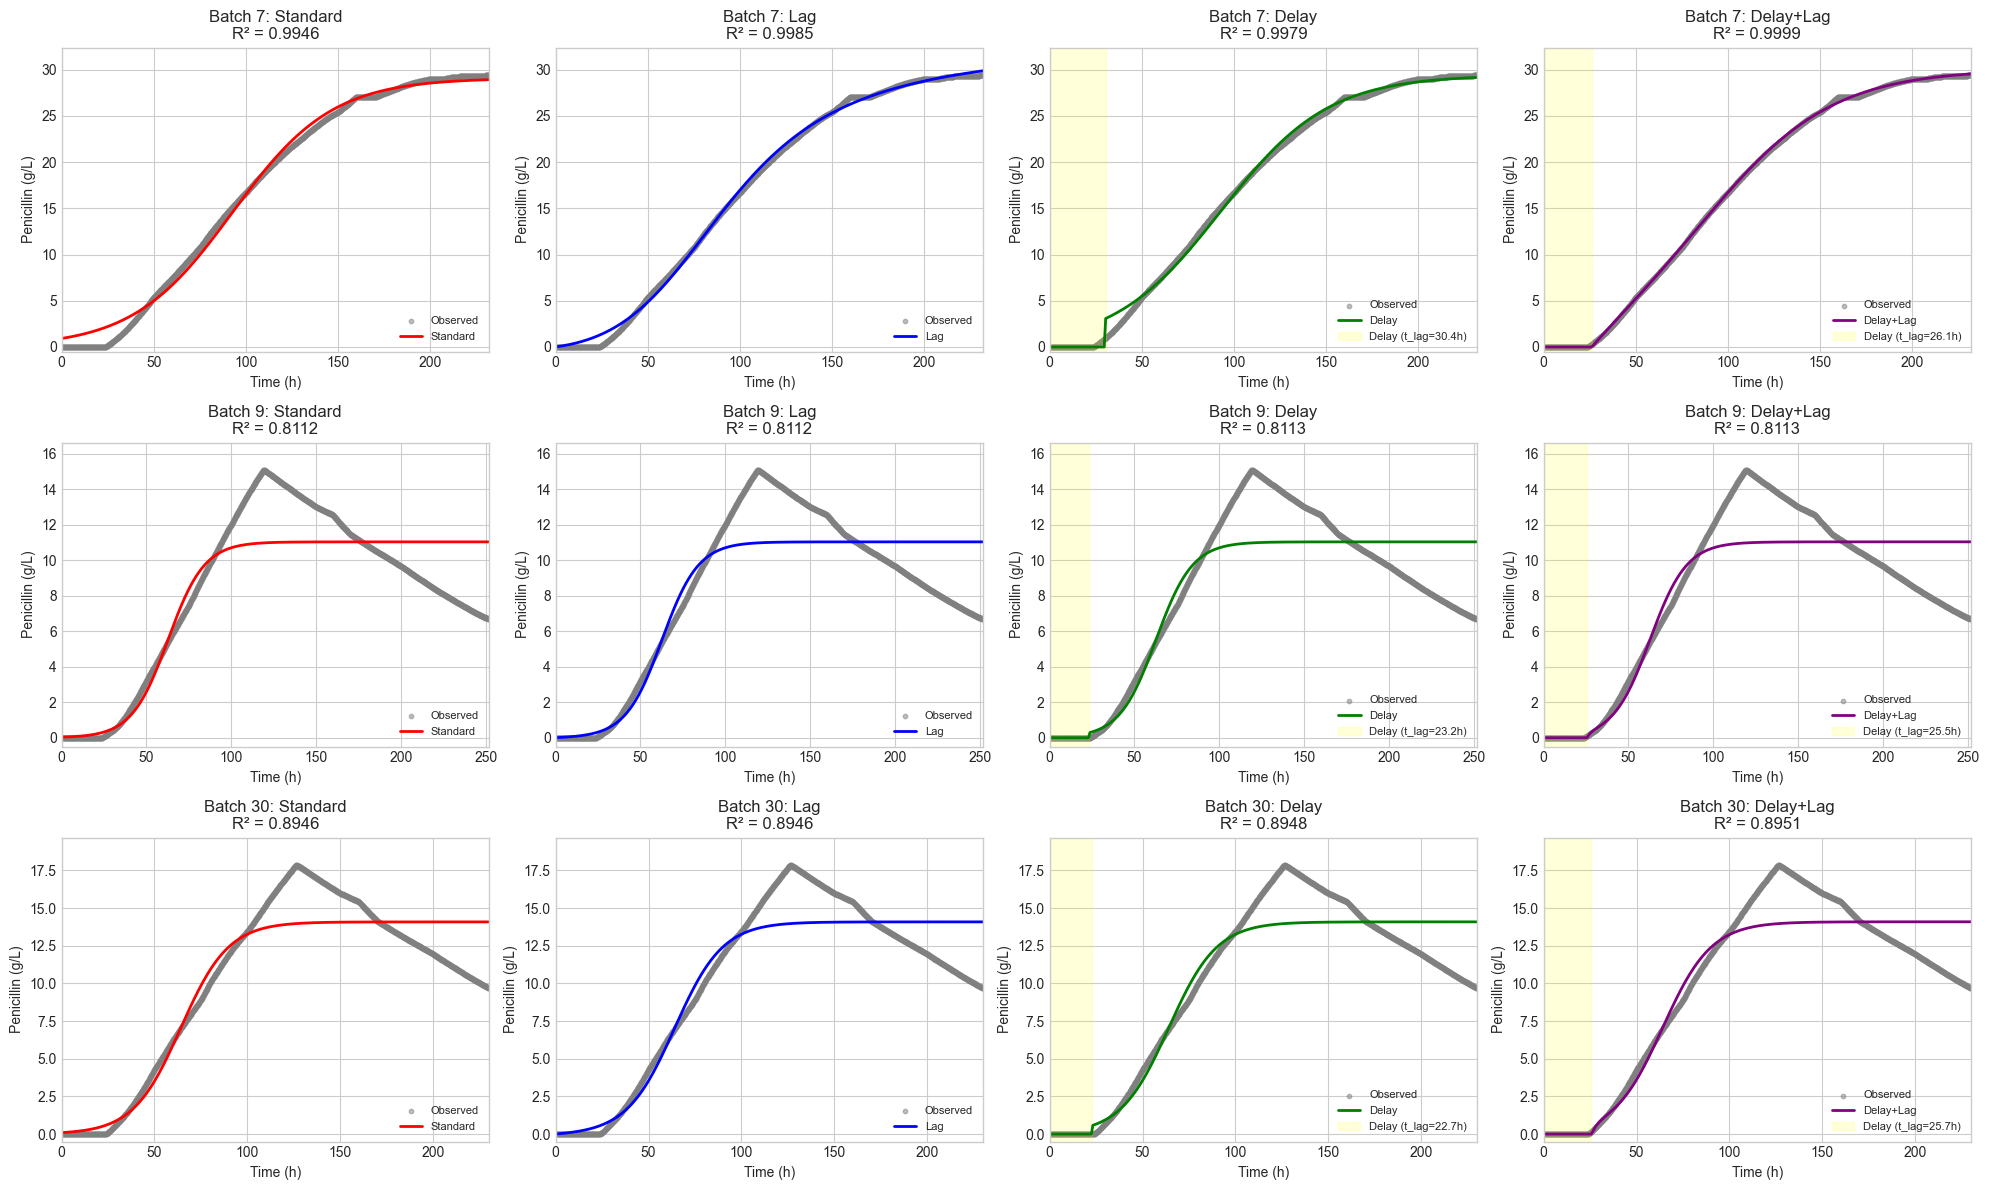

In [25]:
# Visual comparison on worst-fitting batches from standard logistic
compare_batch_ids = [7, 9, 30]

fig, axes = plt.subplots(len(compare_batch_ids), 4, figsize=(20, 4 * len(compare_batch_ids)))

for row, batch_id in enumerate(compare_batch_ids):
    df = batches[batch_id]
    t = df["time"].values
    y = df["P"].values
    mask = ~np.isnan(y)
    t_clean, y_clean = t[mask], y[mask]
    t_smooth = np.linspace(t_clean.min(), t_clean.max(), 300)
    
    # Get fitted parameters for all models
    std_row = fit_df[fit_df["batch_id"] == batch_id].iloc[0]
    lag_row = lag_fit_df[lag_fit_df["batch_id"] == batch_id].iloc[0]
    delay_row = delay_fit_df[delay_fit_df["batch_id"] == batch_id].iloc[0]
    delay_lag_row = delay_lag_fit_df[delay_lag_fit_df["batch_id"] == batch_id].iloc[0]
    
    models = [
        ("Standard", std_row, logistic_growth, ["K", "r", "t0"], "red"),
        ("Lag", lag_row, logistic_with_lag, ["K", "r", "t0", "lam"], "blue"),
        ("Delay", delay_row, logistic_with_delay, ["K", "r", "t0", "t_lag"], "green"),
        ("Delay+Lag", delay_lag_row, logistic_with_delay_and_lag, ["K", "r", "t0", "lam", "t_lag"], "purple"),
    ]
    
    for col, (name, params, func, param_names, color) in enumerate(models):
        ax = axes[row, col]
        
        # Plot observed data
        ax.scatter(t_clean, y_clean, s=10, alpha=0.5, c="gray", label="Observed")
        
        # Plot fitted curve
        param_vals = [params[p] for p in param_names]
        y_fit = func(t_smooth, *param_vals)
        ax.plot(t_smooth, y_fit, color=color, linewidth=2, label=name)
        
        # Mark delay region if applicable
        if "t_lag" in param_names:
            t_lag_val = params["t_lag"]
            ax.axvspan(0, t_lag_val, alpha=0.15, color="yellow", label=f"Delay (t_lag={t_lag_val:.1f}h)")
        
        ax.set_xlabel("Time (h)")
        ax.set_ylabel("Penicillin (g/L)")
        ax.set_title(f"Batch {batch_id}: {name}\nR² = {params['r_squared']:.4f}")
        ax.legend(loc="lower right", fontsize=8)
        ax.set_xlim(0, t_clean.max())
        ax.set_ylim(-0.5, y_clean.max() * 1.1)

plt.tight_layout()
plt.savefig("../outputs/figures/logistic_all_models_comparison.png", dpi=150)
plt.show()

/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/1955801520.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(t_lag_by_mode, labels=modes, patch_artist=True)


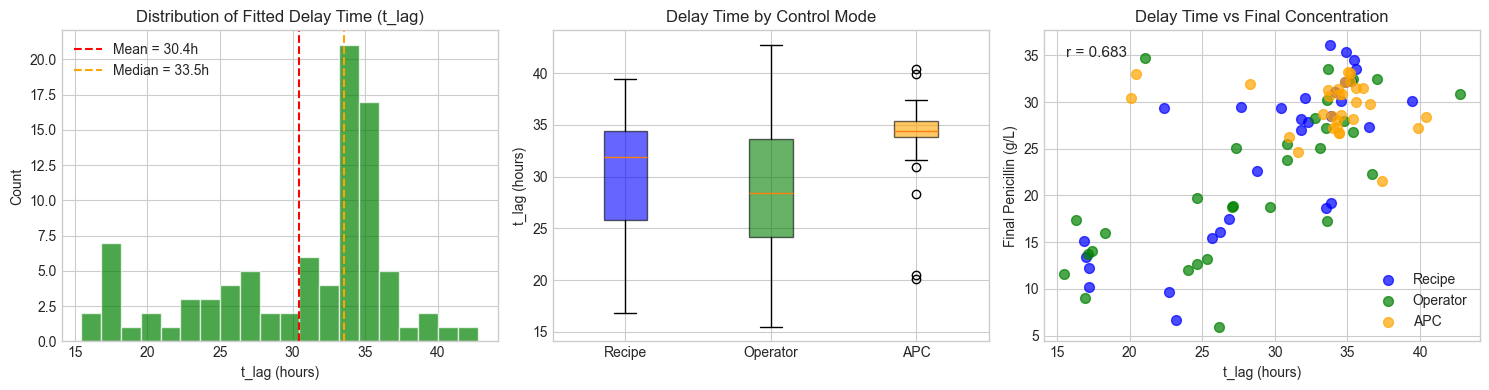

t_lag Statistics:
  Range: 15.5 - 42.8 hours
  Mean:  30.4 ± 6.6 hours

t_lag by Control Mode:
  Recipe: 29.5 ± 6.6 hours
  Operator: 28.1 ± 7.3 hours
  APC: 33.7 ± 4.3 hours


In [28]:
# Show t_lag distribution and its relationship to batch characteristics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. t_lag distribution (Delay model)
ax = axes[0]
ax.hist(delay_fit_df["t_lag"], bins=20, edgecolor="white", alpha=0.7, color="green")
ax.axvline(delay_fit_df["t_lag"].mean(), color="red", linestyle="--", 
           label=f"Mean = {delay_fit_df['t_lag'].mean():.1f}h")
ax.axvline(delay_fit_df["t_lag"].median(), color="orange", linestyle="--", 
           label=f"Median = {delay_fit_df['t_lag'].median():.1f}h")
ax.set_xlabel("t_lag (hours)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Fitted Delay Time (t_lag)")
ax.legend()

# 2. t_lag by control mode
ax = axes[1]
modes = ["Recipe", "Operator", "APC"]
t_lag_by_mode = [delay_fit_df[delay_fit_df["control_mode"] == m]["t_lag"].values for m in modes]
bp = ax.boxplot(t_lag_by_mode, labels=modes, patch_artist=True)
mode_colors = {"Recipe": "blue", "Operator": "green", "APC": "orange"}
for patch, mode in zip(bp["boxes"], modes):
    patch.set_facecolor(mode_colors[mode])
    patch.set_alpha(0.6)
ax.set_ylabel("t_lag (hours)")
ax.set_title("Delay Time by Control Mode")

# 3. t_lag vs final P
ax = axes[2]
for mode in modes:
    subset = delay_fit_df[delay_fit_df["control_mode"] == mode]
    ax.scatter(subset["t_lag"], subset["final_P"], 
               c=mode_colors[mode], label=mode, alpha=0.7, s=50)
ax.set_xlabel("t_lag (hours)")
ax.set_ylabel("Final Penicillin (g/L)")
ax.set_title("Delay Time vs Final Concentration")
ax.legend()

# Compute correlation
corr = delay_fit_df["t_lag"].corr(delay_fit_df["final_P"])
ax.annotate(f"r = {corr:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
            fontsize=11, ha="left", va="top")

plt.tight_layout()
plt.savefig("../outputs/figures/logistic_delay_t_lag_analysis.png", dpi=150)
plt.show()

# Print statistics
print("t_lag Statistics:")
print(f"  Range: {delay_fit_df['t_lag'].min():.1f} - {delay_fit_df['t_lag'].max():.1f} hours")
print(f"  Mean:  {delay_fit_df['t_lag'].mean():.1f} ± {delay_fit_df['t_lag'].std():.1f} hours")
print(f"\nt_lag by Control Mode:")
for mode in modes:
    subset = delay_fit_df[delay_fit_df["control_mode"] == mode]["t_lag"]
    print(f"  {mode}: {subset.mean():.1f} ± {subset.std():.1f} hours")

In [29]:
# Verify P(0) = 0 for delay models
print("Verification: P(0) for each model type")
print("=" * 50)

# Check at t=0 for each model
t_test = np.array([0.0])

# Standard logistic (should NOT be 0)
sample_std = fit_df.iloc[0]
p0_std = logistic_growth(t_test, sample_std["K"], sample_std["r"], sample_std["t0"])[0]
print(f"Standard Logistic P(0):  {p0_std:.4f} g/L (NOT zero)")

# Lag-adjusted (should be 0)
sample_lag = lag_fit_df.iloc[0]
p0_lag = logistic_with_lag(t_test, sample_lag["K"], sample_lag["r"], 
                            sample_lag["t0"], sample_lag["lam"])[0]
print(f"Lag-Adjusted P(0):       {p0_lag:.4f} g/L (zero by design)")

# Delay (should be 0)
sample_delay = delay_fit_df.iloc[0]
p0_delay = logistic_with_delay(t_test, sample_delay["K"], sample_delay["r"], 
                                sample_delay["t0"], sample_delay["t_lag"])[0]
print(f"Delay P(0):              {p0_delay:.4f} g/L (zero by design)")

# Delay+Lag (should be 0)
sample_delay_lag = delay_lag_fit_df.iloc[0]
p0_delay_lag = logistic_with_delay_and_lag(t_test, sample_delay_lag["K"], sample_delay_lag["r"], 
                                            sample_delay_lag["t0"], sample_delay_lag["lam"], 
                                            sample_delay_lag["t_lag"])[0]
print(f"Delay+Lag P(0):          {p0_delay_lag:.4f} g/L (zero by design)")

# Check fitted t_lag values are reasonable (not at boundaries)
print(f"\nt_lag boundary check:")
t_max_typical = 400  # typical batch duration
at_lower = (delay_fit_df["t_lag"] < 1).sum()
at_upper = (delay_fit_df["t_lag"] > t_max_typical * 0.4).sum()
print(f"  Batches with t_lag < 1h (at lower bound): {at_lower}")
print(f"  Batches with t_lag > 40% of batch (at upper bound): {at_upper}")
if at_lower == 0 and at_upper == 0:
    print("  All t_lag values are within reasonable bounds.")

Verification: P(0) for each model type
Standard Logistic P(0):  0.9807 g/L (NOT zero)
Lag-Adjusted P(0):       0.0000 g/L (zero by design)
Delay P(0):              0.0000 g/L (zero by design)
Delay+Lag P(0):          0.0000 g/L (zero by design)

t_lag boundary check:
  Batches with t_lag < 1h (at lower bound): 0
  Batches with t_lag > 40% of batch (at upper bound): 0
  All t_lag values are within reasonable bounds.


### Parameter Distributions by Control Mode

Compare how the logistic growth parameters (K, r, t₀) vary across the three control modes.

/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/1624008674.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_mode, labels=control_modes, patch_artist=True)
/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/1624008674.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_mode, labels=control_modes, patch_artist=True)
/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_80715/1624008674.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_mode, labels=control_modes, patch_artist=True)
/var/folders/s3/fkdq7lzx1

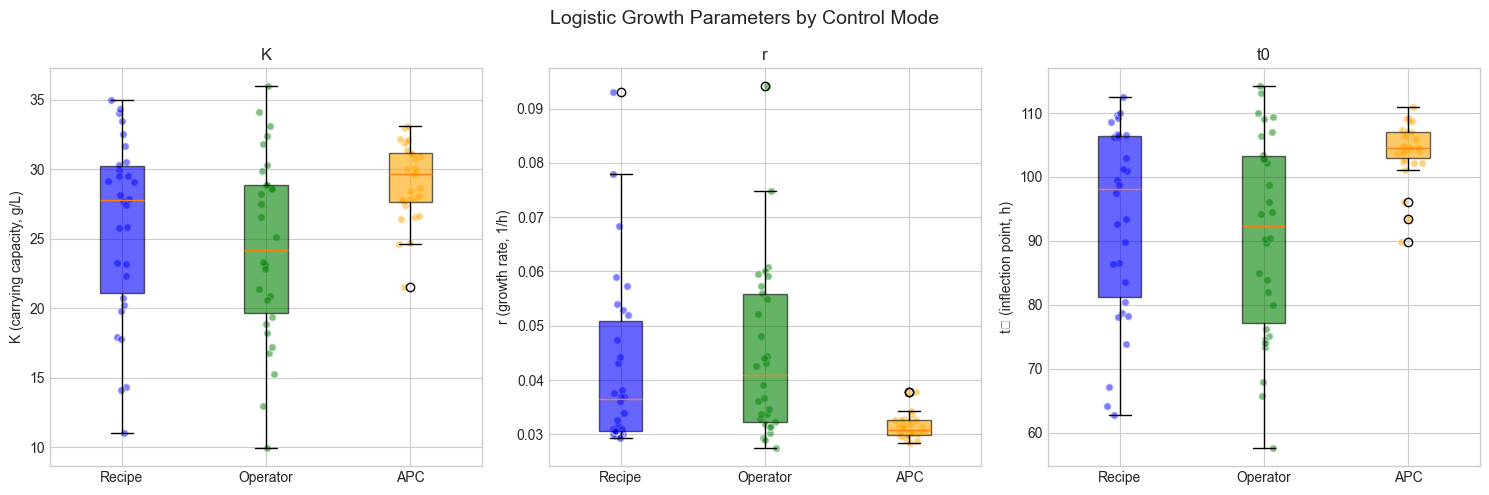

In [30]:
# Compare parameter distributions by control mode
params = ["K", "r", "t0"]
param_labels = ["K (carrying capacity, g/L)", "r (growth rate, 1/h)", "t₀ (inflection point, h)"]
control_modes = ["Recipe", "Operator", "APC"]
colors = {"Recipe": "blue", "Operator": "green", "APC": "orange"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, param, label in zip(axes, params, param_labels):
    data_by_mode = [fit_df[fit_df["control_mode"] == mode][param].values for mode in control_modes]
    
    # Box plot
    bp = ax.boxplot(data_by_mode, labels=control_modes, patch_artist=True)
    for patch, mode in zip(bp["boxes"], control_modes):
        patch.set_facecolor(colors[mode])
        patch.set_alpha(0.6)
    
    # Overlay individual points
    for i, (mode, data) in enumerate(zip(control_modes, data_by_mode)):
        x = np.random.normal(i + 1, 0.04, len(data))
        ax.scatter(x, data, alpha=0.5, s=30, c=colors[mode], edgecolor="white")
    
    ax.set_ylabel(label)
    ax.set_title(param)

plt.suptitle("Logistic Growth Parameters by Control Mode", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_params_by_mode.png", dpi=150)
plt.show()

In [31]:
# Statistical tests for parameter differences between control modes
print("Statistical Tests for Parameter Differences by Control Mode")
print("=" * 60)

stats_results = []

for param, label in zip(params, param_labels):
    recipe = fit_df[fit_df["control_mode"] == "Recipe"][param].values
    operator = fit_df[fit_df["control_mode"] == "Operator"][param].values
    apc = fit_df[fit_df["control_mode"] == "APC"][param].values
    
    # ANOVA (parametric)
    f_stat, anova_p = f_oneway(recipe, operator, apc)
    
    # Kruskal-Wallis (non-parametric)
    h_stat, kruskal_p = kruskal(recipe, operator, apc)
    
    stats_results.append({
        "Parameter": param,
        "Recipe (mean±std)": f"{recipe.mean():.3f}±{recipe.std():.3f}",
        "Operator (mean±std)": f"{operator.mean():.3f}±{operator.std():.3f}",
        "APC (mean±std)": f"{apc.mean():.3f}±{apc.std():.3f}",
        "ANOVA p": f"{anova_p:.4f}",
        "Kruskal p": f"{kruskal_p:.4f}",
        "Significant": "Yes" if kruskal_p < 0.05 else "No",
    })
    
    print(f"\n{label}:")
    print(f"  Recipe:   {recipe.mean():.3f} ± {recipe.std():.3f}")
    print(f"  Operator: {operator.mean():.3f} ± {operator.std():.3f}")
    print(f"  APC:      {apc.mean():.3f} ± {apc.std():.3f}")
    print(f"  ANOVA F={f_stat:.2f}, p={anova_p:.4f}")
    print(f"  Kruskal-Wallis H={h_stat:.2f}, p={kruskal_p:.4f}")

stats_df = pd.DataFrame(stats_results)
print("\n" + "=" * 60)
display(stats_df)

Statistical Tests for Parameter Differences by Control Mode

K (carrying capacity, g/L):
  Recipe:   25.894 ± 6.383
  Operator: 24.467 ± 6.489
  APC:      29.120 ± 2.686
  ANOVA F=5.49, p=0.0057
  Kruskal-Wallis H=8.07, p=0.0177

r (growth rate, 1/h):
  Recipe:   0.042 ± 0.016
  Operator: 0.045 ± 0.015
  APC:      0.031 ± 0.002
  ANOVA F=8.86, p=0.0003
  Kruskal-Wallis H=18.55, p=0.0001

t₀ (inflection point, h):
  Recipe:   93.290 ± 14.665
  Operator: 90.991 ± 15.407
  APC:      104.230 ± 4.487
  ANOVA F=9.21, p=0.0002
  Kruskal-Wallis H=12.09, p=0.0024



,Parameter,Recipe (mean±std),Operator (mean±std),APC (mean±std),ANOVA p,Kruskal p,Significant
0,K,25.894±6.383,24.467±6.489,29.120±2.686,0.0057,0.0177,Yes
1,r,0.042±0.016,0.045±0.015,0.031±0.002,0.0003,0.0001,Yes
2,t0,93.290±14.665,90.991±15.407,104.230±4.487,0.0002,0.0024,Yes


### Relationship Between Logistic Parameters and Input Features

Examine correlations between the fitted logistic parameters and early-window feature statistics to understand what drives differences in growth dynamics.

/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


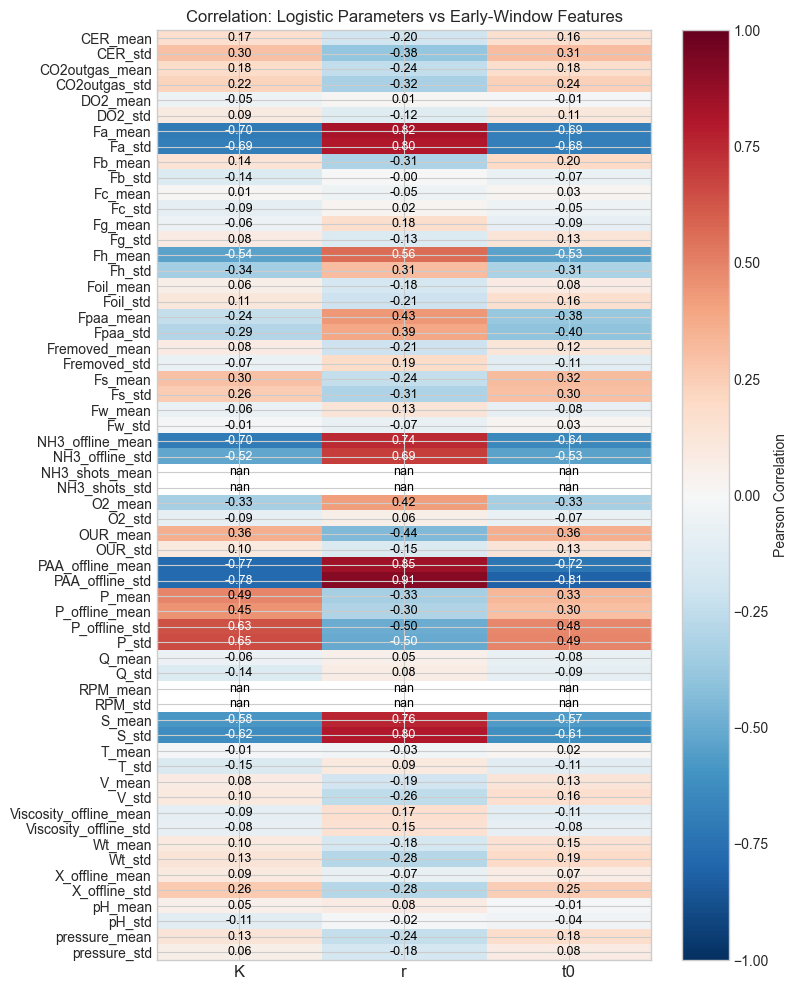


Strongest correlations with logistic parameters:
  K: PAA_offline_std (r = -0.779)
  r: PAA_offline_std (r = 0.912)
  t0: PAA_offline_std (r = -0.808)


In [32]:
WINDOW_SIZE = 0.7 # test window size

# Compute early-window feature statistics for each batch
key_features = [
    'Fg', 'RPM', 'Fs', 'Fa', 'Fb', 'Fc', 'Fh', 'Fw', 'pressure',
    'Fremoved', 'S', 'DO2', 'P', 'V', 'Wt', 'pH', 'T', 'Q', 'CO2outgas',
    'Fpaa', 'PAA_offline', 'Foil', 'NH3_offline', 'OUR', 'O2', 'P_offline',
    'X_offline', 'CER', 'NH3_shots', 'Viscosity_offline'
]

feature_stats = []
for batch_id in fit_df["batch_id"]:
    df = batches[batch_id]
    early = extract_early_window(df, WINDOW_SIZE)
    
    row = {"batch_id": batch_id}
    for feat in key_features:
        if feat in early.columns:
            row[f"{feat}_mean"] = early[feat].mean()
            row[f"{feat}_std"] = early[feat].std()
    feature_stats.append(row)

feature_df = pd.DataFrame(feature_stats)

# Merge with logistic parameters
merged = fit_df.merge(feature_df, on="batch_id")

# Compute correlations between parameters and features
feature_cols = [c for c in merged.columns if "_mean" in c or "_std" in c]
corr_data = []

for param in ["K", "r", "t0"]:
    for feat_col in feature_cols:
        corr = merged[param].corr(merged[feat_col])
        corr_data.append({"Parameter": param, "Feature": feat_col, "Correlation": corr})

corr_df = pd.DataFrame(corr_data).pivot(index="Feature", columns="Parameter", values="Correlation")

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, fontsize=12)
ax.set_yticks(range(len(corr_df.index)))
ax.set_yticklabels(corr_df.index, fontsize=10)

# Add correlation values as text
for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        val = corr_df.values[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)

plt.colorbar(im, ax=ax, label="Pearson Correlation")
ax.set_title("Correlation: Logistic Parameters vs Early-Window Features")
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_params_feature_corr.png", dpi=150)
plt.show()

# Show strongest correlations
print("\nStrongest correlations with logistic parameters:")
for param in ["K", "r", "t0"]:
    param_corrs = corr_df[param].abs().sort_values(ascending=False)
    top_feat = param_corrs.index[0]
    print(f"  {param}: {top_feat} (r = {corr_df.loc[top_feat, param]:.3f})")

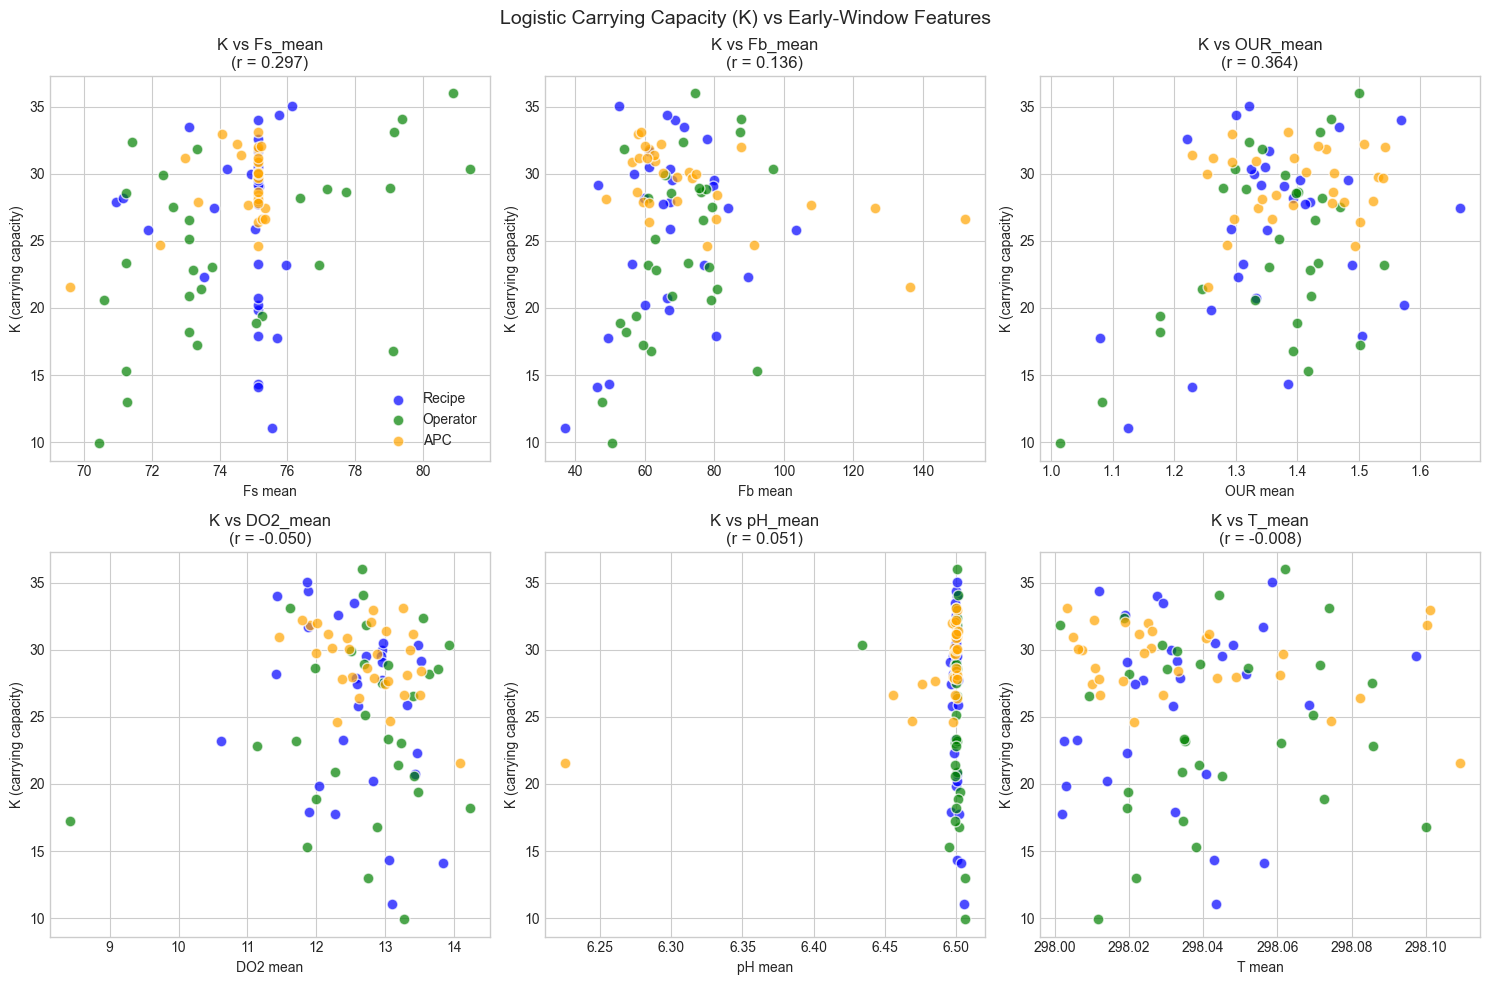

In [33]:
# Scatter plots: K vs key features, colored by control mode
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

scatter_features = ["Fs_mean", "Fb_mean", "OUR_mean", "DO2_mean", "pH_mean", "T_mean"]

for ax, feat in zip(axes.flatten(), scatter_features):
    for mode in control_modes:
        subset = merged[merged["control_mode"] == mode]
        ax.scatter(subset[feat], subset["K"], 
                   c=colors[mode], label=mode, alpha=0.7, s=60, edgecolor="white")
    
    ax.set_xlabel(feat.replace("_", " "))
    ax.set_ylabel("K (carrying capacity)")
    
    # Add correlation
    r = merged["K"].corr(merged[feat])
    ax.set_title(f"K vs {feat}\n(r = {r:.3f})")

axes[0, 0].legend()
plt.suptitle("Logistic Carrying Capacity (K) vs Early-Window Features", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_K_vs_features.png", dpi=150)
plt.show()

### Three-Stage Model with Decline Phase

Some batches show a **decline phase** after reaching peak concentration, where penicillin degrades or is consumed. The standard logistic models assume monotonic growth and cannot capture this behavior.

**Three-Phase Model:**

$$P(t) = \begin{cases} 
0 & t < t_{lag} \\
f_{logistic}(t - t_{lag}) \cdot (1 - e^{-\lambda(t - t_{lag})}) & t_{lag} \leq t < t_{break} \\
P(t_{break}) - slope \cdot (t - t_{break}) & t \geq t_{break}
\end{cases}$$

**Parameters (7 total):**
- K, r, t₀, λ, t_lag: Same as delay+lag model
- **t_break**: Onset of decline phase (fitted)
- **slope**: Rate of linear decline (fitted, non-negative)

For batches without decline, the optimizer will naturally converge `slope → 0`.

In [34]:
# Fit three-stage model to all non-fault batches
decline_fit_results = []

for batch_id in range(1, 91):
    df = batches[batch_id]
    result = fit_logistic_with_decline_batch(df)
    
    if result is not None:
        result["batch_id"] = batch_id
        result["control_mode"] = get_control_mode(batch_id)
        decline_fit_results.append(result)

decline_fit_df = pd.DataFrame(decline_fit_results)
print(f"Successfully fitted {len(decline_fit_df)} / 90 batches")
print(f"\nThree-stage model R² summary:")
print(decline_fit_df["r_squared"].describe())
print(f"\nBatches with significant decline phase: {decline_fit_df['has_decline'].sum()} / {len(decline_fit_df)}")

Successfully fitted 90 / 90 batches

Three-stage model R² summary:
count    90.000000
mean      0.999647
std       0.000423
min       0.996718
25%       0.999641
50%       0.999751
75%       0.999854
max       0.999939
Name: r_squared, dtype: float64

Batches with significant decline phase: 35 / 90


In [35]:
# Compare R² between delay+lag model and three-stage model
comparison_df = delay_lag_fit_df[["batch_id", "control_mode", "r_squared"]].copy()
comparison_df = comparison_df.rename(columns={"r_squared": "r2_delay_lag"})

comparison_df = comparison_df.merge(
    decline_fit_df[["batch_id", "r_squared", "has_decline", "t_break", "slope"]].rename(
        columns={"r_squared": "r2_decline"}
    ),
    on="batch_id"
)

comparison_df["r2_improvement"] = comparison_df["r2_decline"] - comparison_df["r2_delay_lag"]

print("Model Comparison Summary:")
print(f"  Mean R² (delay+lag):    {comparison_df['r2_delay_lag'].mean():.6f}")
print(f"  Mean R² (three-stage):  {comparison_df['r2_decline'].mean():.6f}")
print(f"  Mean improvement:       {comparison_df['r2_improvement'].mean():.6f}")

print("\nBatches with biggest R² improvement (three-stage vs delay+lag):")
display(comparison_df.sort_values("r2_improvement", ascending=False)[
    ["batch_id", "control_mode", "r2_delay_lag", "r2_decline", "r2_improvement", "has_decline", "slope"]
].head(10))

print("\nBatches with R² < 0.90 in delay+lag model:")
poor_fit_batches = comparison_df[comparison_df["r2_delay_lag"] < 0.90]
display(poor_fit_batches[["batch_id", "control_mode", "r2_delay_lag", "r2_decline", "r2_improvement", "has_decline"]])

Model Comparison Summary:
  Mean R² (delay+lag):    0.980317
  Mean R² (three-stage):  0.999647
  Mean improvement:       0.019330

Batches with biggest R² improvement (three-stage vs delay+lag):


,batch_id,control_mode,r2_delay_lag,r2_decline,r2_improvement,has_decline,slope
44,45,Operator,0.772589,0.996718,0.224129,True,0.060437
8,9,Recipe,0.811319,0.998167,0.186847,True,0.066924
24,25,Recipe,0.887791,0.999518,0.111727,True,0.109706
32,33,Operator,0.891033,0.999678,0.108645,True,0.120878
29,30,Recipe,0.895062,0.999722,0.104660,True,0.080329
50,51,Operator,0.904258,0.999741,0.095483,True,0.076530
17,18,Recipe,0.910171,0.998441,0.088270,True,0.084885
42,43,Operator,0.922272,0.999741,0.077469,True,0.106524
33,34,Operator,0.933051,0.999719,0.066668,True,0.109908
2,3,Recipe,0.932422,0.998981,0.066560,True,0.129582



Batches with R² < 0.90 in delay+lag model:


,batch_id,control_mode,r2_delay_lag,r2_decline,r2_improvement,has_decline
8,9,Recipe,0.811319,0.998167,0.186847,True
24,25,Recipe,0.887791,0.999518,0.111727,True
29,30,Recipe,0.895062,0.999722,0.104660,True
32,33,Operator,0.891033,0.999678,0.108645,True
44,45,Operator,0.772589,0.996718,0.224129,True


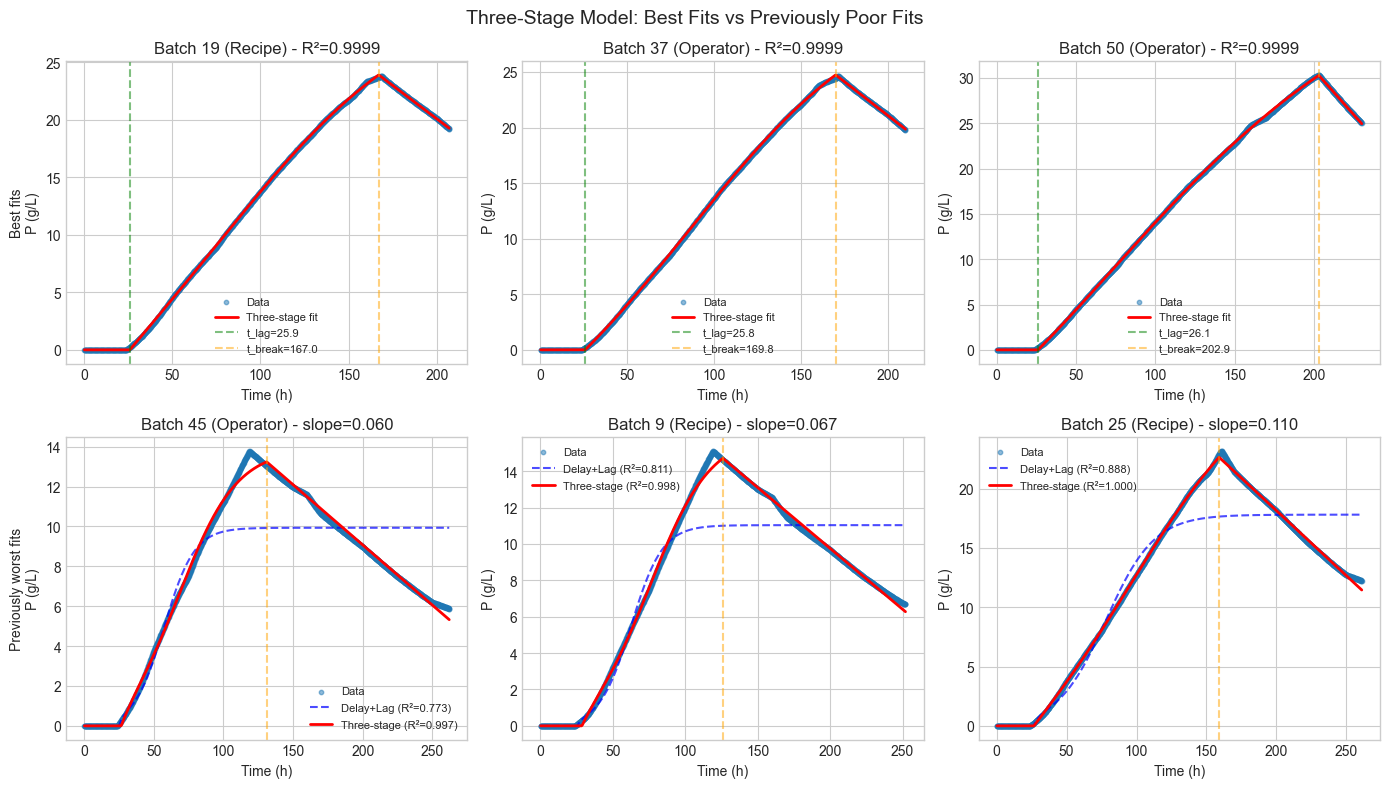

In [36]:
# Visualize best and worst fits with three-stage model
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Top row: Best fits (should remain good)
best_fit_ids = decline_fit_df.nlargest(3, "r_squared")["batch_id"].values
for ax, batch_id in zip(axes[0], best_fit_ids):
    df = batches[batch_id]
    t = df["time"].values
    P = df["P"].values
    
    # Get fitted parameters
    row = decline_fit_df[decline_fit_df["batch_id"] == batch_id].iloc[0]
    popt = [row["K"], row["r"], row["t0"], row["lam"], row["t_lag"], row["t_break"], row["slope"]]
    
    t_smooth = np.linspace(t.min(), t.max(), 500)
    P_fit = logistic_with_decline(t_smooth, *popt)
    
    ax.scatter(t, P, alpha=0.5, s=10, label="Data")
    ax.plot(t_smooth, P_fit, 'r-', linewidth=2, label="Three-stage fit")
    ax.axvline(row["t_lag"], color="green", linestyle="--", alpha=0.5, label=f"t_lag={row['t_lag']:.1f}")
    ax.axvline(row["t_break"], color="orange", linestyle="--", alpha=0.5, label=f"t_break={row['t_break']:.1f}")
    ax.set_title(f"Batch {batch_id} ({row['control_mode']}) - R²={row['r_squared']:.4f}")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P (g/L)")
    ax.legend(fontsize=8)

# Bottom row: Previously worst fits (should improve)
# Find batches that had poor fit with delay+lag but improved with three-stage
worst_before = comparison_df.nsmallest(3, "r2_delay_lag")["batch_id"].values
for ax, batch_id in zip(axes[1], worst_before):
    df = batches[batch_id]
    t = df["time"].values
    P = df["P"].values
    
    # Three-stage fit
    row_decline = decline_fit_df[decline_fit_df["batch_id"] == batch_id].iloc[0]
    popt = [row_decline["K"], row_decline["r"], row_decline["t0"], row_decline["lam"], 
            row_decline["t_lag"], row_decline["t_break"], row_decline["slope"]]
    
    # Delay+lag fit for comparison
    row_delay_lag = delay_lag_fit_df[delay_lag_fit_df["batch_id"] == batch_id].iloc[0]
    popt_dl = [row_delay_lag["K"], row_delay_lag["r"], row_delay_lag["t0"], 
               row_delay_lag["lam"], row_delay_lag["t_lag"]]
    
    t_smooth = np.linspace(t.min(), t.max(), 500)
    P_fit_decline = logistic_with_decline(t_smooth, *popt)
    P_fit_dl = logistic_with_delay_and_lag(t_smooth, *popt_dl)
    
    ax.scatter(t, P, alpha=0.5, s=10, label="Data")
    ax.plot(t_smooth, P_fit_dl, 'b--', linewidth=1.5, alpha=0.7, label=f"Delay+Lag (R²={row_delay_lag['r_squared']:.3f})")
    ax.plot(t_smooth, P_fit_decline, 'r-', linewidth=2, label=f"Three-stage (R²={row_decline['r_squared']:.3f})")
    ax.axvline(row_decline["t_break"], color="orange", linestyle="--", alpha=0.5)
    ax.set_title(f"Batch {batch_id} ({row_decline['control_mode']}) - slope={row_decline['slope']:.3f}")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("P (g/L)")
    ax.legend(fontsize=8)

axes[0, 0].set_ylabel("Best fits\nP (g/L)")
axes[1, 0].set_ylabel("Previously worst fits\nP (g/L)")

plt.suptitle("Three-Stage Model: Best Fits vs Previously Poor Fits", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/three_stage_model_comparison.png", dpi=150)
plt.show()

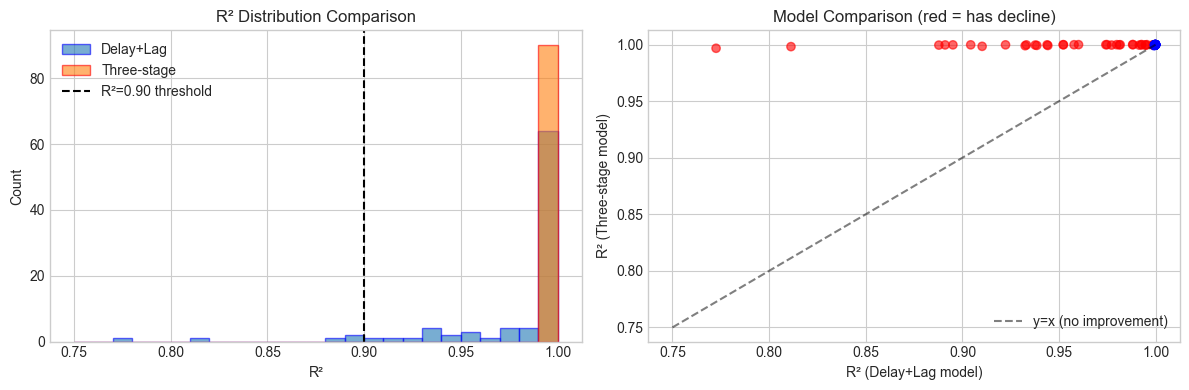


R² Summary by Model:
  Batches with R² < 0.90 (delay+lag):    5
  Batches with R² < 0.90 (three-stage):  0
  Batches with R² > 0.99 (delay+lag):    64
  Batches with R² > 0.99 (three-stage):  90


In [37]:
# R² distribution comparison: delay+lag vs three-stage
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of R² values
ax = axes[0]
bins = np.linspace(0.75, 1.0, 26)
ax.hist(comparison_df["r2_delay_lag"], bins=bins, alpha=0.6, label="Delay+Lag", edgecolor="blue")
ax.hist(comparison_df["r2_decline"], bins=bins, alpha=0.6, label="Three-stage", edgecolor="red")
ax.axvline(0.90, color="black", linestyle="--", label="R²=0.90 threshold")
ax.set_xlabel("R²")
ax.set_ylabel("Count")
ax.set_title("R² Distribution Comparison")
ax.legend()

# Scatter plot: delay+lag R² vs three-stage R²
ax = axes[1]
colors = comparison_df["has_decline"].map({True: "red", False: "blue"})
ax.scatter(comparison_df["r2_delay_lag"], comparison_df["r2_decline"], c=colors, alpha=0.6)
ax.plot([0.75, 1.0], [0.75, 1.0], 'k--', alpha=0.5, label="y=x (no improvement)")
ax.set_xlabel("R² (Delay+Lag model)")
ax.set_ylabel("R² (Three-stage model)")
ax.set_title("Model Comparison (red = has decline)")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/three_stage_r2_comparison.png", dpi=150)
plt.show()

# Summary statistics
print("\nR² Summary by Model:")
print(f"  Batches with R² < 0.90 (delay+lag):    {(comparison_df['r2_delay_lag'] < 0.90).sum()}")
print(f"  Batches with R² < 0.90 (three-stage):  {(comparison_df['r2_decline'] < 0.90).sum()}")
print(f"  Batches with R² > 0.99 (delay+lag):    {(comparison_df['r2_delay_lag'] > 0.99).sum()}")
print(f"  Batches with R² > 0.99 (three-stage):  {(comparison_df['r2_decline'] > 0.99).sum()}")

### Summary: Logistic Growth Model Analysis

**Five Models Compared:**

| Model | Parameters | P(0) | Description |
|-------|------------|------|-------------|
| Standard Logistic | K, r, t₀ (3) | ≠ 0 | Basic sigmoid |
| Lag-Adjusted | K, r, t₀, λ (4) | = 0 | Smooth approach to zero via $(1 - e^{-\lambda t})$ |
| **Delay** | K, r, t₀, t_lag (4) | = 0 | Hard cutoff: P=0 for t < t_lag |
| **Delay+Lag** | K, r, t₀, λ, t_lag (5) | = 0 | Combines explicit delay + smooth onset |
| **Three-Stage** | K, r, t₀, λ, t_lag, t_break, slope (7) | = 0 | Delay + growth + optional decline phase |

**Fit Quality:**
- The standard logistic growth model provides good fits for most batches (median R² > 0.98)
- Batches with distinct lag phases show poor early-time fits (R² as low as 0.77)
- Models with P(0)=0 constraint generally perform better
- **The three-stage model improves fits for batches with late-stage decline**

**Three-Stage Model:**
- Extends delay+lag with optional linear decline after t_break
- For batches without decline, optimizer converges to slope ≈ 0
- Captures degradation/consumption dynamics in some batches
- Most improvement seen in previously poor-fit batches (R² < 0.90)

**Piecewise Delay Model:**
- The delay models explicitly set P(t) = 0 for t < t_lag (hard cutoff)
- t_lag is fitted from data, capturing the true delay duration
- Useful for batches where no penicillin is produced during initial phase
- The fitted t_lag parameter has biological interpretation as lag phase duration

**When to Use Each Model:**
- **Standard**: Quick baseline, but overshoots at t=0
- **Lag-Adjusted**: Best for continuous smooth onset from zero
- **Delay**: Best when data shows clear zero plateau before growth
- **Delay+Lag**: Most flexible for monotonic growth with explicit delay
- **Three-Stage**: Best when late-stage decline is observed

**Parameter Differences by Control Mode:**
- Significant differences in K, r, t₀ between Recipe, Operator, and APC control modes
- APC batches show higher K, lower r, and later t₀ (slower but higher yield)
- t_lag may also vary by control mode

**Implications for UDA:**
- Control modes have systematically different growth dynamics
- Domain adaptation must account for these underlying process differences
- Features that correlate strongly with K are good candidates for prediction
- The logistic parameter differences provide insight into what makes domains differ